# Home Credit Default dataset 

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import os
from millify import millify

from pathlib import Path
from tkinter import Tk
from tkinter.filedialog import askdirectory

### Set up the file path

In [3]:
data_dir=Path('../home_credit_data')
eda_output = Path("../eda_outputs/")
cleaned_data_path = Path('../streamlit/cleaned_data')

## Load the data

In [4]:
if not data_dir.exists():
    root = Tk()
    root.withdraw()
    data_dir = Path(askdirectory(title='Select Home Credit Data Directory (csv files)'))

In [ ]:
train= pd.read_csv(data_dir/'application_train.csv')
test= pd.read_csv(data_dir/'application_test.csv')
bb=pd.read_csv(data_dir/'bureau_balance.csv')
bureau=pd.read_csv(data_dir/'bureau.csv')
prev=pd.read_csv(data_dir/'previous_application.csv')
cc= pd.read_csv(data_dir/'credit_card_balance.csv')
pcb= pd.read_csv(data_dir/'POS_CASH_balance.csv')
ip=pd.read_csv(data_dir/'installments_payments.csv')

## Application Train

In [419]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 2000)          # or 2000
pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', '{:.6f}'.format)
np.set_printoptions(suppress=True)

### Basic exploration application train/test

In [420]:
train['CODE_GENDER'].value_counts(normalize=True)

CODE_GENDER
F     0.658344
M     0.341643
XNA   0.000013
Name: proportion, dtype: float64

In [421]:
preview=train.head(5).T
preview['missing%']=train.isna().mean().mul(100).round(6)
preview

,0,1,2,3,4,missing%
SK_ID_CURR,100002,100003,100004,100006,100007,0.000000
TARGET,1,0,0,0,0,0.000000
NAME_CONTRACT_TYPE,Cash loans,Cash loans,Revolving loans,Cash loans,Cash loans,0.000000
CODE_GENDER,M,F,M,F,M,0.000000
FLAG_OWN_CAR,N,N,Y,N,N,0.000000
FLAG_OWN_REALTY,Y,N,Y,Y,Y,0.000000
CNT_CHILDREN,0,0,0,0,0,0.000000
AMT_INCOME_TOTAL,202500.000000,270000.000000,67500.000000,135000.000000,121500.000000,0.000000
AMT_CREDIT,406597.500000,1293502.500000,135000.000000,312682.500000,513000.000000,0.000000
AMT_ANNUITY,24700.500000,35698.500000,6750.000000,29686.500000,21865.500000,0.003902


In [422]:
train[(train[['APARTMENTS_AVG','LIVINGAPARTMENTS_AVG','NONLIVINGAPARTMENTS_AVG','WALLSMATERIAL_MODE','NONLIVINGAREA_AVG','BASEMENTAREA_AVG', 'COMMONAREA_AVG', 
             'LIVINGAREA_AVG','TOTALAREA_MODE','FLOORSMIN_AVG','FLOORSMAX_AVG',
             'LANDAREA_AVG', 'HOUSETYPE_MODE']].isna().all(axis=1))&(train['YEARS_BEGINEXPLUATATION_MODE'].notna())][['YEARS_BEGINEXPLUATATION_MODE','APARTMENTS_AVG','LIVINGAPARTMENTS_AVG','NONLIVINGAPARTMENTS_AVG','WALLSMATERIAL_MODE','NONLIVINGAREA_AVG','BASEMENTAREA_AVG', 'COMMONAREA_AVG', 
             'LIVINGAREA_AVG','TOTALAREA_MODE','FLOORSMIN_AVG','FLOORSMAX_AVG',
             'LANDAREA_AVG', 'HOUSETYPE_MODE']].head(20)

,YEARS_BEGINEXPLUATATION_MODE,APARTMENTS_AVG,LIVINGAPARTMENTS_AVG,NONLIVINGAPARTMENTS_AVG,WALLSMATERIAL_MODE,NONLIVINGAREA_AVG,BASEMENTAREA_AVG,COMMONAREA_AVG,LIVINGAREA_AVG,TOTALAREA_MODE,FLOORSMIN_AVG,FLOORSMAX_AVG,LANDAREA_AVG,HOUSETYPE_MODE
14638,0.977700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36627,0.980600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
144725,0.997000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
177239,0.983100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
237856,0.983600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [423]:
train['YEARS_BEGINEXPLUATATION_MODE'].corr(train['TARGET'])

np.float64(-0.009036447354301163)

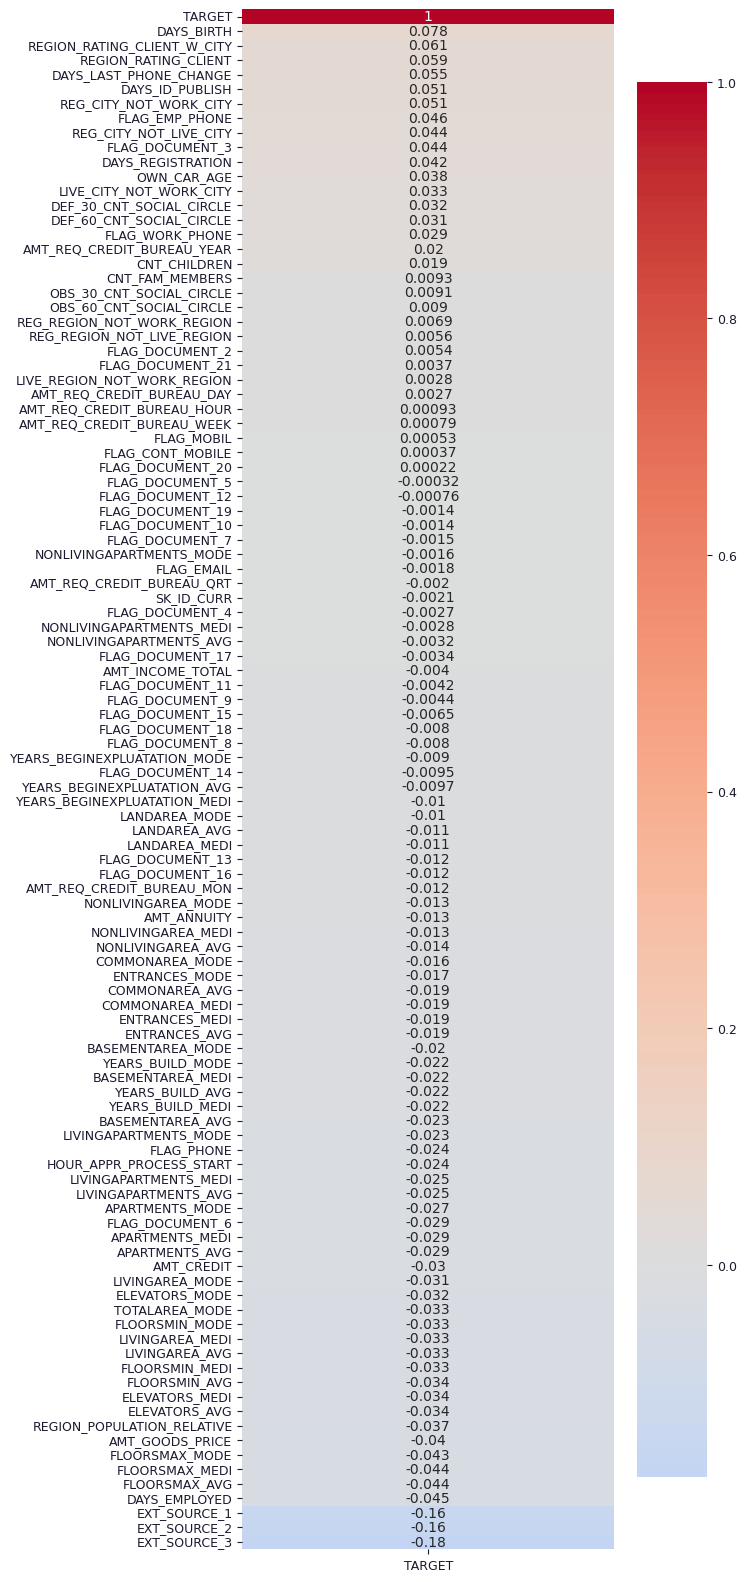

In [424]:
corr_target = (
    train.corr(numeric_only=True)[['TARGET']]
    .sort_values('TARGET', ascending=False)
)

plt.figure(figsize=(6,20))
sns.heatmap(corr_target,
            annot=True,
            cmap='coolwarm',
            center=0)
plt.show()

In [425]:
train.groupby('HOUSETYPE_MODE',dropna=False)['TARGET'].mean().sort_values(ascending=False)

HOUSETYPE_MODE
specific housing   0.101401
NaN                0.091512
terraced house     0.084983
block of flats     0.069434
Name: TARGET, dtype: float64

In [426]:
train.loc[
    train['NAME_TYPE_SUITE'].isna(),
    ['NAME_TYPE_SUITE', 'NAME_FAMILY_STATUS','CNT_CHILDREN','CNT_FAM_MEMBERS']
].head(20)

,NAME_TYPE_SUITE,NAME_FAMILY_STATUS,CNT_CHILDREN,CNT_FAM_MEMBERS
64,NaN,Married,0,2.000000
724,NaN,Married,2,4.000000
1199,NaN,Civil marriage,0,2.000000
1669,NaN,Separated,2,3.000000
1862,NaN,Married,0,2.000000
2271,NaN,Single / not married,0,1.000000
2625,NaN,Married,1,3.000000
2650,NaN,Married,0,2.000000
3012,NaN,Married,0,2.000000
3050,NaN,Married,2,4.000000


In [427]:
train.loc[
    train['NAME_TYPE_SUITE'].notna(),
    ['NAME_TYPE_SUITE', 'NAME_FAMILY_STATUS']
].head(50)

,NAME_TYPE_SUITE,NAME_FAMILY_STATUS
0,Unaccompanied,Single / not married
1,Family,Married
2,Unaccompanied,Single / not married
3,Unaccompanied,Civil marriage
4,Unaccompanied,Single / not married
5,"Spouse, partner",Married
6,Unaccompanied,Married
7,Unaccompanied,Married
8,Children,Married
9,Unaccompanied,Single / not married


In [428]:
train.groupby(
    train['NAME_TYPE_SUITE'].isna()
)['TARGET'].agg(['count','mean'])

,count,mean
NAME_TYPE_SUITE,,
False,306219,0.080841
True,1292,0.054180


In [429]:
train.groupby(
    train['NAME_TYPE_SUITE'].fillna('Missing')
)['TARGET'].agg(['count','mean'])

,count,mean
NAME_TYPE_SUITE,,
Children,3267,0.073768
Family,40149,0.074946
Group of people,271,0.084871
Missing,1292,0.054180
Other_A,866,0.087760
Other_B,1770,0.098305
"Spouse, partner",11370,0.078716
Unaccompanied,248526,0.081830


In [430]:
car_cols = [col for col in train.columns if 'car' in col.lower()]

car_summary = train[car_cols].head(10).T
car_summary['Missing%'] = train[car_cols].isna().mean().mul(100)
car_summary

,0,1,2,3,4,5,6,7,8,9,Missing%
FLAG_OWN_CAR,N,N,Y,N,N,N,Y,Y,N,N,0.000000
OWN_CAR_AGE,NaN,NaN,26.000000,NaN,NaN,NaN,17.000000,8.000000,NaN,NaN,65.990810


In [431]:
train.loc[train['OCCUPATION_TYPE'].isna(),'ORGANIZATION_TYPE'].unique()

array(['XNA', 'Military', 'Business Entity Type 3', 'Emergency',
       'University', 'School', 'Industry: type 4', 'Transport: type 4',
       'Business Entity Type 1', 'Other', 'Hotel', 'Industry: type 7',
       'Self-employed', 'Trade: type 3', 'Bank', 'Business Entity Type 2',
       'Housing', 'Transport: type 1', 'Industry: type 9', 'Medicine',
       'Kindergarten', 'Industry: type 11', 'Trade: type 7',
       'Agriculture', 'Electricity', 'Transport: type 2', 'Government',
       'Services', 'Industry: type 1', 'Security', 'Police', 'Restaurant',
       'Transport: type 3', 'Security Ministries', 'Industry: type 3',
       'Trade: type 6', 'Industry: type 5', 'Mobile', 'Culture',
       'Construction', 'Industry: type 12', 'Insurance', 'Telecom',
       'Postal', 'Trade: type 2', 'Legal Services', 'Industry: type 10',
       'Advertising', 'Trade: type 1', 'Industry: type 6',
       'Industry: type 2', 'Religion', 'Realtor', 'Cleaning',
       'Industry: type 13', 'Industry: t

In [432]:
train.loc[train['OCCUPATION_TYPE'].isna(),'NAME_INCOME_TYPE'].unique()

array(['Pensioner', 'State servant', 'Commercial associate', 'Working',
       'Unemployed', 'Student', 'Maternity leave', 'Businessman'],
      dtype=object)

In [433]:
medi_mode_avg_cols = [col for col in train.columns if col.endswith(('_AVG'))]
df = train[medi_mode_avg_cols]
su = df.head(10).T
su['missing%'] = train[medi_mode_avg_cols].isna().mean().mul(100).round(6)
su.sort_index()

,0,1,2,3,4,5,6,7,8,9,missing%
APARTMENTS_AVG,0.024700,0.095900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.749729
BASEMENTAREA_AVG,0.036900,0.052900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58.515956
COMMONAREA_AVG,0.014300,0.060500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,69.872297
ELEVATORS_AVG,0.000000,0.080000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,53.295980
ENTRANCES_AVG,0.069000,0.034500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.348768
FLOORSMAX_AVG,0.083300,0.291700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49.760822
FLOORSMIN_AVG,0.125000,0.333300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,67.848630
LANDAREA_AVG,0.036900,0.013000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,59.376738
LIVINGAPARTMENTS_AVG,0.020200,0.077300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68.354953
LIVINGAREA_AVG,0.019000,0.054900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.193326


In [434]:
# first check correlations between area columns
area_cols = ['APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'COMMONAREA_AVG', 
             'LIVINGAREA_AVG', 'NONLIVINGAREA_AVG', 'TOTALAREA_MODE',
             'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG']

train[area_cols].corr()

,APARTMENTS_AVG,BASEMENTAREA_AVG,COMMONAREA_AVG,LIVINGAREA_AVG,NONLIVINGAREA_AVG,TOTALAREA_MODE,LANDAREA_AVG,LIVINGAPARTMENTS_AVG
APARTMENTS_AVG,1.000000,0.679389,0.538900,0.913619,0.299719,0.892627,0.496852,0.943952
BASEMENTAREA_AVG,0.679389,1.000000,0.405459,0.692891,0.266349,0.672400,0.467661,0.646774
COMMONAREA_AVG,0.538900,0.405459,1.000000,0.547030,0.227615,0.553260,0.257046,0.533103
LIVINGAREA_AVG,0.913619,0.692891,0.547030,1.000000,0.302101,0.925039,0.501571,0.880798
NONLIVINGAREA_AVG,0.299719,0.266349,0.227615,0.302101,1.000000,0.366604,0.163538,0.293276
TOTALAREA_MODE,0.892627,0.672400,0.553260,0.925039,0.366604,1.000000,0.491091,0.848028
LANDAREA_AVG,0.496852,0.467661,0.257046,0.501571,0.163538,0.491091,1.000000,0.420084
LIVINGAPARTMENTS_AVG,0.943952,0.646774,0.533103,0.880798,0.293276,0.848028,0.420084,1.000000


In [435]:
# Check missing pattern
area_cols = ['APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'COMMONAREA_AVG', 
             'LIVINGAREA_AVG', 'NONLIVINGAREA_AVG', 'TOTALAREA_MODE',
             'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG']

# If all rows have same missing pattern this will be all True
train[area_cols].isna().sum()

APARTMENTS_AVG          156061
BASEMENTAREA_AVG        179943
COMMONAREA_AVG          214865
LIVINGAREA_AVG          154350
NONLIVINGAREA_AVG       169682
TOTALAREA_MODE          148431
LANDAREA_AVG            182590
LIVINGAPARTMENTS_AVG    210199
dtype: int64

In [436]:
train[train['APARTMENTS_AVG'].notna()][['APARTMENTS_AVG','LIVINGAPARTMENTS_AVG','NONLIVINGAPARTMENTS_AVG','WALLSMATERIAL_MODE','NONLIVINGAREA_AVG','BASEMENTAREA_AVG', 'COMMONAREA_AVG', 
             'LIVINGAREA_AVG','TOTALAREA_MODE','FLOORSMIN_AVG','FLOORSMAX_AVG',
             'LANDAREA_AVG', 'HOUSETYPE_MODE']].head(20)

,APARTMENTS_AVG,LIVINGAPARTMENTS_AVG,NONLIVINGAPARTMENTS_AVG,WALLSMATERIAL_MODE,NONLIVINGAREA_AVG,BASEMENTAREA_AVG,COMMONAREA_AVG,LIVINGAREA_AVG,TOTALAREA_MODE,FLOORSMIN_AVG,FLOORSMAX_AVG,LANDAREA_AVG,HOUSETYPE_MODE
0,0.024700,0.020200,0.000000,"Stone, brick",0.000000,0.036900,0.014300,0.019000,0.014900,0.125000,0.083300,0.036900,block of flats
1,0.095900,0.077300,0.003900,Block,0.009800,0.052900,0.060500,0.054900,0.071400,0.333300,0.291700,0.013000,block of flats
12,0.082500,NaN,NaN,NaN,0.000000,NaN,NaN,0.077800,0.061200,NaN,0.166700,0.013500,block of flats
13,0.147400,0.120200,0.000000,Panel,0.000000,0.097300,0.058200,0.139700,0.141700,0.375000,0.333300,0.093100,block of flats
14,0.349500,0.284900,0.019300,Panel,0.100100,0.133500,0.114300,0.377400,0.381100,0.708300,0.666700,0.175800,block of flats
18,0.027800,0.022700,0.000000,"Stone, brick",0.000000,0.061700,0.001800,0.029000,0.023800,0.125000,0.083300,0.027900,block of flats
20,0.072200,0.058800,0.000000,"Stone, brick",0.000000,0.080100,NaN,0.061900,0.053000,0.041700,0.166700,0.053400,block of flats
22,0.090700,0.072300,0.007700,Panel,0.004400,0.079500,0.012000,0.087300,0.069600,0.208300,0.166700,0.089800,block of flats
23,0.144300,0.117300,0.001900,Mixed,0.000700,0.084800,0.106400,0.148400,0.164000,0.416700,0.375000,0.237100,block of flats
24,0.143300,0.116800,0.000000,Panel,0.004300,0.145500,0.021200,0.121700,0.096700,0.208300,0.166700,0.086100,block of flats


In [437]:
train['HOUSETYPE_MODE'].value_counts(normalize=True,dropna=False)

HOUSETYPE_MODE
NaN                0.501761
block of flats     0.489423
specific housing   0.004875
terraced house     0.003941
Name: proportion, dtype: float64

In [438]:
train[(train['HOUSETYPE_MODE'].isna())& (train[['APARTMENTS_AVG','LIVINGAPARTMENTS_AVG','BASEMENTAREA_AVG', 'COMMONAREA_AVG', 
             'LIVINGAREA_AVG', 'NONLIVINGAREA_AVG', 'TOTALAREA_MODE',
             'LANDAREA_AVG', 'HOUSETYPE_MODE']].notna().any(axis=1))][['APARTMENTS_AVG','LIVINGAPARTMENTS_AVG','WALLSMATERIAL_MODE','BASEMENTAREA_AVG', 'COMMONAREA_AVG', 
             'LIVINGAREA_AVG', 'NONLIVINGAREA_AVG', 'TOTALAREA_MODE',
             'LANDAREA_AVG', 'HOUSETYPE_MODE']].head(20)

,APARTMENTS_AVG,LIVINGAPARTMENTS_AVG,WALLSMATERIAL_MODE,BASEMENTAREA_AVG,COMMONAREA_AVG,LIVINGAREA_AVG,NONLIVINGAREA_AVG,TOTALAREA_MODE,LANDAREA_AVG,HOUSETYPE_MODE
102,NaN,NaN,Panel,0.111700,NaN,0.098700,NaN,0.077600,NaN,NaN
114,NaN,NaN,NaN,NaN,NaN,0.236500,NaN,0.268800,NaN,NaN
147,0.055700,NaN,Panel,NaN,NaN,0.038300,0.002800,0.030800,0.036100,NaN
174,NaN,NaN,Wooden,NaN,NaN,NaN,NaN,0.002600,NaN,NaN
214,0.034000,NaN,"Stone, brick",NaN,NaN,0.026900,0.000000,0.021200,NaN,NaN
218,0.072200,NaN,"Stone, brick",0.057500,0.013700,NaN,NaN,0.037600,NaN,NaN
319,0.033000,0.026900,Block,0.037400,0.009300,0.032700,0.025200,0.033600,0.008700,NaN
399,NaN,NaN,Panel,0.401300,NaN,0.097600,0.070700,0.092100,NaN,NaN
409,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.238600,NaN,NaN
458,0.008200,NaN,NaN,NaN,0.001400,0.006300,NaN,0.005700,NaN,NaN


In [439]:
# Check all building related columns
building_related = [col for col in train.columns if any(keyword in col.upper() for keyword in 
                    ['APART', 'AREA', 'FLOOR', 'HOUSE', 'LAND', 'LIVING', 
                     'BASEMENT', 'COMMON', 'ENTRANCE', 'ELEVATOR', 
                     'WALL', 'FONDKA', 'NONLIVING', 'YEARS_BUILD',
                     'YEARS_BEGIN', 'EMERGENCYSTATE', 'TOTALAREA'])]

print(building_related)
print(len(building_related))

['APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMAX_MODE', 'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMAX_MEDI', 'FLOORSMIN_MEDI', 'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MEDI', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'TOTALAREA_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']
47


In [440]:
train.FONDKAPREMONT_MODE.unique()

array(['reg oper account', nan, 'org spec account',
       'reg oper spec account', 'not specified'], dtype=object)

In [441]:
doc_cols = [col for col in train.columns if 'FLAG_DOCUMENT' in col]
train[doc_cols].mean().sort_values(ascending=False)

FLAG_DOCUMENT_3    0.710023
FLAG_DOCUMENT_6    0.088055
FLAG_DOCUMENT_8    0.081376
FLAG_DOCUMENT_5    0.015115
FLAG_DOCUMENT_16   0.009928
FLAG_DOCUMENT_18   0.008130
FLAG_DOCUMENT_11   0.003912
FLAG_DOCUMENT_9    0.003896
FLAG_DOCUMENT_13   0.003525
FLAG_DOCUMENT_14   0.002936
FLAG_DOCUMENT_15   0.001210
FLAG_DOCUMENT_19   0.000595
FLAG_DOCUMENT_20   0.000507
FLAG_DOCUMENT_21   0.000335
FLAG_DOCUMENT_17   0.000267
FLAG_DOCUMENT_7    0.000192
FLAG_DOCUMENT_4    0.000081
FLAG_DOCUMENT_2    0.000042
FLAG_DOCUMENT_10   0.000023
FLAG_DOCUMENT_12   0.000007
dtype: float64

In [442]:
doc_cols = [col for col in train.columns if 'FLAG_DOCUMENT' in col]

# Mean target rate for each document flag
doc_target = pd.DataFrame({
    'submitted_default_rate'    : train.groupby(doc_cols[0])['TARGET'].mean(),
})

# Better — check all at once
result = []
for col in doc_cols:
    rates = train.groupby(col)['TARGET'].mean()
    result.append({
        'document'          : col,
        'submission_rate'   : train[col].mean().round(4),
        'default_if_NO'     : rates.get(0, None).round(4),
        'default_if_YES'    : rates.get(1, None).round(4),
        'difference'        : (rates.get(0, 0) - rates.get(1, 0)).round(4)
    })

doc_analysis = pd.DataFrame(result).sort_values('difference', ascending=False)
doc_analysis

,document,submission_rate,default_if_NO,default_if_YES,difference
2,FLAG_DOCUMENT_4,0.000100,0.080700,0.000000,0.080700
10,FLAG_DOCUMENT_12,0.000000,0.080700,0.000000,0.080700
8,FLAG_DOCUMENT_10,0.000000,0.080700,0.000000,0.080700
15,FLAG_DOCUMENT_17,0.000300,0.080700,0.024400,0.056400
11,FLAG_DOCUMENT_13,0.003500,0.080900,0.027700,0.053200
13,FLAG_DOCUMENT_15,0.001200,0.080800,0.029600,0.051200
12,FLAG_DOCUMENT_14,0.002900,0.080900,0.033200,0.047600
14,FLAG_DOCUMENT_16,0.009900,0.081000,0.049100,0.031900
5,FLAG_DOCUMENT_7,0.000200,0.080700,0.050800,0.029900
4,FLAG_DOCUMENT_6,0.088100,0.083100,0.055700,0.027500


In [443]:
from scipy.stats import pearsonr

result = []
for col in doc_cols:
    corr, pval = pearsonr(train[col], train['TARGET'])
    result.append({
        'document'   : col,
        'corr'       : round(corr, 4),
        'pvalue'     : round(pval, 4),
        'significant': 'YES' if pval < 0.05 else 'NO'
    })

pd.DataFrame(result).sort_values('corr', key=abs, ascending=False)

,document,corr,pvalue,significant
1,FLAG_DOCUMENT_3,0.044300,0.000000,YES
4,FLAG_DOCUMENT_6,-0.028600,0.000000,YES
11,FLAG_DOCUMENT_13,-0.011600,0.000000,YES
14,FLAG_DOCUMENT_16,-0.011600,0.000000,YES
12,FLAG_DOCUMENT_14,-0.009500,0.000000,YES
6,FLAG_DOCUMENT_8,-0.008000,0.000000,YES
16,FLAG_DOCUMENT_18,-0.008000,0.000000,YES
13,FLAG_DOCUMENT_15,-0.006500,0.000300,YES
0,FLAG_DOCUMENT_2,0.005400,0.002700,YES
7,FLAG_DOCUMENT_9,-0.004400,0.015800,YES


In [444]:
print(train['EMERGENCYSTATE_MODE'].value_counts(normalize=True,dropna=False))
print('\nDefault rate per category:')
print(train.groupby('EMERGENCYSTATE_MODE', dropna=False)['TARGET'].mean())

EMERGENCYSTATE_MODE
No    0.518446
NaN   0.473983
Yes   0.007570
Name: proportion, dtype: float64

Default rate per category:
EMERGENCYSTATE_MODE
No    0.069649
Yes   0.095790
NaN   0.092607
Name: TARGET, dtype: float64


In [445]:
# WALLSMATERIAL_MODE
print("WALLSMATERIAL_MODE distribution:")
print(train['WALLSMATERIAL_MODE'].value_counts(normalize=True, dropna=False))
print('\nDefault rate per category:')
print(train.groupby('WALLSMATERIAL_MODE', dropna=False)['TARGET'].mean().sort_values(ascending=False))

WALLSMATERIAL_MODE distribution:
WALLSMATERIAL_MODE
NaN            0.508408
Panel          0.214757
Stone, brick   0.210773
Block          0.030090
Wooden         0.017437
Mixed          0.007466
Monolithic     0.005785
Others         0.005284
Name: proportion, dtype: float64

Default rate per category:
WALLSMATERIAL_MODE
Wooden         0.096979
NaN            0.091281
Others         0.083077
Mixed          0.075348
Stone, brick   0.074057
Block          0.070247
Panel          0.063477
Monolithic     0.047218
Name: TARGET, dtype: float64


In [446]:
# HOUSETYPE_MODE
print("HOUSETYPE_MODE distribution:")
print(train['HOUSETYPE_MODE'].value_counts(normalize=True, dropna=False))
print('\nDefault rate per category:')
print(train.groupby('HOUSETYPE_MODE', dropna=False)['TARGET'].mean().sort_values(ascending=False))

HOUSETYPE_MODE distribution:
HOUSETYPE_MODE
NaN                0.501761
block of flats     0.489423
specific housing   0.004875
terraced house     0.003941
Name: proportion, dtype: float64

Default rate per category:
HOUSETYPE_MODE
specific housing   0.101401
NaN                0.091512
terraced house     0.084983
block of flats     0.069434
Name: TARGET, dtype: float64


In [447]:
test.EMERGENCYSTATE_MODE.value_counts(normalize=True,dropna=False)

EMERGENCYSTATE_MODE
No    0.537071
NaN   0.455625
Yes   0.007303
Name: proportion, dtype: float64

### data cleaning Application train/test

In [448]:
# ============================================================
# 1. NAME_TYPE_SUITE
# ============================================================
for df in [train, test]:
    df['NAME_TYPE_SUITE'] = df['NAME_TYPE_SUITE'].fillna('Missing')

# ============================================================
# 2. CNT_FAM_MEMBERS
# ============================================================
for df in [train, test]:
    married = df['NAME_FAMILY_STATUS'].isin(['Married', 'Civil marriage'])
    df['CNT_FAM_MEMBERS'] = df['CNT_FAM_MEMBERS'].fillna(
        df['CNT_CHILDREN'] + 1 + married.astype(int)
    )

# ============================================================
# 3. OWN_CAR_AGE — drop (too many nulls, FLAG_OWN_CAR exists)
# ============================================================
for df in [train, test]:
    df.drop(columns='OWN_CAR_AGE', inplace=True)

# ============================================================
# 4. EXT_SOURCE_1/2/3 — average into one column
# ============================================================
for df in [train, test]:
    df['EXT_SOURCE_MEAN'] = df[['EXT_SOURCE_1',
                                 'EXT_SOURCE_2',
                                 'EXT_SOURCE_3']].mean(axis=1)
    df.drop(columns=['EXT_SOURCE_1',
                     'EXT_SOURCE_2',
                     'EXT_SOURCE_3'], inplace=True)

# Drop rows where all three were missing (~0.06%)
train.dropna(subset=['EXT_SOURCE_MEAN'], inplace=True)
test.dropna(subset=['EXT_SOURCE_MEAN'],  inplace=True)

# ============================================================
# 5. BUILDING / HOUSE COLUMNS
# ============================================================

# --- 5a. Identify all building related columns
building_related = [col for col in train.columns if any(
    keyword in col.upper() for keyword in
    ['APART', 'AREA', 'FLOOR', 'HOUSE', 'LAND', 'LIVING',
     'BASEMENT', 'COMMON', 'ENTRANCE', 'ELEVATOR',
     'WALL', 'FONDKA', 'NONLIVING', 'YEARS_BUILD',
     'YEARS_BEGIN', 'TOTALAREA'])]

# --- 5b. HAS_BUILDING_INFO flag
for df in [train, test]:
    df['HAS_BUILDING_INFO'] = df[building_related].notna().any(axis=1).astype(int)


# --- 5c. EMERGENCYSTATE_MODE → IS_HIGH_RISK_BUILDING
for df in [train, test]:
    df['IS_HIGH_RISK_BUILDING'] = (
        df['EMERGENCYSTATE_MODE'] != 'No'
    ).astype(int)
    # No  = safe  = 0
    # Yes = emergency = 1
    # NaN = unknown ≈ high risk = 1

# --- 5d. WALLSMATERIAL_MODE → WALL_RISK (3 tier)
for df in [train, test]:
    df['WALL_RISK'] = df['WALLSMATERIAL_MODE'].map({
        'Monolithic'  : 0,   # lowest risk  4.7%
        'Panel'       : 0,   # low risk     6.3%
        'Block'       : 1,   # medium risk  7.0%
        'Stone, brick': 1,   # medium risk  7.4%
        'Mixed'       : 1,   # medium risk  7.5%
        'Others'      : 2,   # high risk    8.3%
        'Wooden'      : 2,   # high risk    9.7%
    }).fillna(2)             # NaN          9.1% → high risk

# --- 5e. HOUSETYPE_MODE → IS_LOW_RISK_HOUSETYPE
for df in [train, test]:
    df['IS_LOW_RISK_HOUSETYPE'] = (
        df['HOUSETYPE_MODE'] == 'block of flats'
    ).astype(int)
    # block of flats = 1 (low risk  6.9%)
    # everything else + NaN = 0 (higher risk 8.5-10%)

# --- 5f. Drop all building AVG/MODE/MEDI columns
drop_building = [col for col in train.columns if
                 col.endswith(('_AVG', '_MEDI','_MODE')) or
                 col in ['HOUSETYPE_MODE', 'WALLSMATERIAL_MODE',
                         'FONDKAPREMONT_MODE', 'EMERGENCYSTATE_MODE','YEARS_BEGINEXPLUATATION_MODE','YEARS_BEGINEXPLUATATION_MEDI']]

for df in [train, test]:
    df.drop(columns=[c for c in drop_building if c in df.columns],
            inplace=True)

# ============================================================
# 6. AMT_REQ_CREDIT_BUREAU — fill with 0
# ============================================================
bureau_cols = ['AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY',
               'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON',
               'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR']

for df in [train, test]:
    df[bureau_cols] = df[bureau_cols].fillna(0)

# ============================================================
# 7. FLAG_DOCUMENT columns — sum into TOTAL_DOCUMENTS
# ============================================================
doc_cols = [col for col in train.columns if 'FLAG_DOCUMENT' in col]

for df in [train, test]:
    df['TOTAL_DOCUMENTS'] = df[doc_cols].sum(axis=1)
    df.drop(columns=doc_cols, inplace=True)

# ============================================================
# 8. SOCIAL CIRCLE — fill with 0
# ============================================================
social_cols = ['OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE',
               'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE']

for df in [train, test]:
    df[social_cols] = df[social_cols].fillna(0)

# ============================================================
# 9. ['AMT_ANNUITY', 'AMT_GOODS_PRICE', 'OCCUPATION_TYPE']
# ============================================================
for df in [train,test]:
    for cols in ['AMT_ANNUITY', 'AMT_GOODS_PRICE']:
        df[cols] = df[cols].fillna(df[cols].median())
    df['OCCUPATION_TYPE'] = df['OCCUPATION_TYPE'].fillna('Missing')

# ============================================================
# 10. Days employes - 365243
# ============================================================
train['DAYS_EMPLOYED'] = train['DAYS_EMPLOYED'].replace(365243, np.nan)
train['DAYS_EMPLOYED'] = train['DAYS_EMPLOYED'].fillna(0)

# ============================================================
# 10. CATEGORIES PRESENT IN TRAIN BUT NOT IN TEST
# ============================================================
train.drop(train[train['CODE_GENDER'] == 'XNA'].index,inplace=True)
train.drop(train[train['NAME_FAMILY_STATUS'] == 'Unknown'].index,inplace=True)
train.reset_index(drop=True, inplace=True)

# ============================================================
# 11. RARE CATEGORIES WITH SIMILAR RISK
# ============================================================
for df in [train, test]:
    df['NAME_TYPE_SUITE'] = df['NAME_TYPE_SUITE'].replace({
        'Other_A': 'Other',
        'Other_B': 'Other',
        'Group of people': 'Other'
        })
    rare_income = [
    'Unemployed',
    'Student',
    'Businessman',
    'Maternity leave'
    ]
    df['NAME_INCOME_TYPE'] = df['NAME_INCOME_TYPE'].replace(
    dict.fromkeys(rare_income, 'Other')
)
    
# ============================================================
# 12. constant columns (nunique <=1)
# ============================================================
for col in train.columns:
    if train[col].nunique() <=1:
        for df in [train, test]:
            df.drop(columns=col, inplace=True)
            
# ============================================================
# 13. LOAN_TO_INCOME ratio
# ============================================================
for df in [train, test]:
    df['LOAN_TO_INCOME'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']
# ============================================================
# FINAL VERIFICATION
# ============================================================
print("Train shape:", train.shape)
print("Test shape :", test.shape)
print("\nRemaining nulls in train (top 20):")
null_pct = train.isna().mean().mul(100).round(2)
print(null_pct[null_pct > 0].sort_values(ascending=False).head(20))

print("\nNew engineered features:")
new_cols = ['EXT_SOURCE_MEAN', 'HAS_BUILDING_INFO', 'IS_HIGH_RISK_BUILDING',
            'WALL_RISK', 'IS_LOW_RISK_HOUSETYPE', 'TOTAL_DOCUMENTS']
print(train[new_cols].describe())

print("\nCorrelation with TARGET:")
print(train[new_cols].corrwith(train['TARGET']).sort_values(ascending=False))

Train shape: (307333, 57)
Test shape : (48737, 56)

Remaining nulls in train (top 20):
Series([], dtype: float64)

New engineered features:
       EXT_SOURCE_MEAN  HAS_BUILDING_INFO  IS_HIGH_RISK_BUILDING     WALL_RISK  IS_LOW_RISK_HOUSETYPE  TOTAL_DOCUMENTS
count    307333.000000      307333.000000          307333.000000 307333.000000          307333.000000    307333.000000
mean          0.509251           0.518278               0.481543      1.310569               0.489424         0.930170
std           0.149803           0.499667               0.499660      0.809466               0.499889         0.344283
min           0.000006           0.000000               0.000000      0.000000               0.000000         0.000000
25%           0.413648           0.000000               0.000000      1.000000               0.000000         1.000000
50%           0.524502           1.000000               0.000000      2.000000               0.000000         1.000000
75%           0.622818     

## bureau_balance

### basic exploration - bureau_balance

In [449]:
check=bb.head(10).T
check['missing%']=bb.isna().mean().mul(100)
check


,0,1,2,3,4,5,6,7,8,9,missing%
SK_ID_BUREAU,5715448,5715448,5715448,5715448,5715448,5715448,5715448,5715448,5715448,5715448,0.000000
MONTHS_BALANCE,0,-1,-2,-3,-4,-5,-6,-7,-8,-9,0.000000
STATUS,C,C,C,C,C,C,C,C,C,0,0.000000


In [450]:
bb.STATUS.unique()

array(['C', '0', 'X', '1', '2', '3', '5', '4'], dtype=object)

## bureau

### basic exploration - bureau

In [451]:
check=bureau.head(10).T
check['missing%'] = bureau.isna().mean().mul(100)
check

,0,1,2,3,4,5,6,7,8,9,missing%
SK_ID_CURR,215354,215354,215354,215354,215354,215354,215354,162297,162297,162297,0.000000
SK_ID_BUREAU,5714462,5714463,5714464,5714465,5714466,5714467,5714468,5714469,5714470,5714471,0.000000
CREDIT_ACTIVE,Closed,Active,Active,Active,Active,Active,Active,Closed,Closed,Active,0.000000
CREDIT_CURRENCY,currency 1,currency 1,currency 1,currency 1,currency 1,currency 1,currency 1,currency 1,currency 1,currency 1,0.000000
DAYS_CREDIT,-497,-208,-203,-203,-629,-273,-43,-1896,-1146,-1146,0.000000
CREDIT_DAY_OVERDUE,0,0,0,0,0,0,0,0,0,0,0.000000
DAYS_CREDIT_ENDDATE,-153.000000,1075.000000,528.000000,NaN,1197.000000,27460.000000,79.000000,-1684.000000,-811.000000,-484.000000,6.149573
DAYS_ENDDATE_FACT,-153.000000,NaN,NaN,NaN,NaN,NaN,NaN,-1710.000000,-840.000000,NaN,36.916958
AMT_CREDIT_MAX_OVERDUE,NaN,NaN,NaN,NaN,77674.500000,0.000000,0.000000,14985.000000,0.000000,0.000000,65.513264
CNT_CREDIT_PROLONG,0,0,0,0,0,0,0,0,0,0,0.000000


In [452]:
bureau.CREDIT_CURRENCY.value_counts(normalize=True)

CREDIT_CURRENCY
currency 1   0.999180
currency 2   0.000713
currency 3   0.000101
currency 4   0.000006
Name: proportion, dtype: float64

In [453]:
bureau[bureau['AMT_CREDIT_SUM'].isna()][['AMT_CREDIT_SUM_LIMIT','CREDIT_TYPE','CREDIT_ACTIVE']].head(20)

,AMT_CREDIT_SUM_LIMIT,CREDIT_TYPE,CREDIT_ACTIVE
218508,NaN,Another type of loan,Active
314570,NaN,Another type of loan,Active
572703,NaN,Another type of loan,Active
585311,NaN,Another type of loan,Closed
590328,NaN,Another type of loan,Closed
814128,NaN,Another type of loan,Active
987620,NaN,Another type of loan,Active
1055762,NaN,Consumer credit,Active
1113131,NaN,Another type of loan,Closed
1172368,NaN,Another type of loan,Closed


In [454]:
pd.crosstab(
    bureau['CREDIT_ACTIVE'],
    bureau['AMT_CREDIT_SUM_DEBT'].isna()
)

AMT_CREDIT_SUM_DEBT,False,True
CREDIT_ACTIVE,,
Active,557060,73547
Bad debt,15,6
Closed,898730,180543
Sold,2954,3573


In [455]:
bureau['AMT_CREDIT_SUM_DEBT'].describe().T

count     1458759.000000
mean       137085.119952
std        677401.130952
min      -4705600.320000
25%             0.000000
50%             0.000000
75%         40153.500000
max     170100000.000000
Name: AMT_CREDIT_SUM_DEBT, dtype: float64

In [456]:
(bureau['AMT_CREDIT_SUM_DEBT'] < 0).sum()/len(bureau)*100

np.float64(0.4904371170826856)

In [457]:
bureau.loc[
    bureau['AMT_CREDIT_SUM_DEBT'] < 0,
    ['CREDIT_ACTIVE',
     'AMT_CREDIT_SUM',
     'AMT_CREDIT_SUM_DEBT']
].head(20)

,CREDIT_ACTIVE,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT
21,Active,0.000000,-411.615000
87,Closed,99000.000000,-2692.170000
88,Closed,135000.000000,-149.040000
89,Active,4500.000000,-2.565000
125,Closed,225000.000000,-701.280000
166,Active,0.000000,-45.360000
225,Active,135000.000000,-638.100000
236,Closed,337500.000000,-15.255000
297,Closed,180000.000000,-455.805000
300,Active,135000.000000,-45.000000


In [458]:
bureau.groupby(
    bureau['AMT_CREDIT_SUM_DEBT'] < 0
)['CREDIT_ACTIVE'].value_counts()

AMT_CREDIT_SUM_DEBT  CREDIT_ACTIVE
False                Closed           1077077
                     Active            624385
                     Sold                6527
                     Bad debt              21
True                 Active              6222
                     Closed              2196
Name: count, dtype: int64

In [459]:
bureau.groupby(
    bureau['AMT_CREDIT_SUM_DEBT'] < 0
)['AMT_CREDIT_SUM'].mean()

AMT_CREDIT_SUM_DEBT
False   356301.194590
True     89887.269066
Name: AMT_CREDIT_SUM, dtype: float64

In [460]:
bureau.groupby(
    bureau['AMT_ANNUITY'].isna()
)['CREDIT_TYPE'].value_counts()

AMT_ANNUITY  CREDIT_TYPE                                 
False        Consumer credit                                 357357
             Credit card                                     109484
             Car loan                                          8991
             Mortgage                                          6441
             Microloan                                         6217
             Loan for business development                      600
             Loan for working capital replenishment             222
             Another type of loan                               177
             Unknown type of loan                                97
             Cash loan (non-earmarked)                           34
             Real estate loan                                     8
             Loan for the purchase of equipment                   7
             Loan for purchase of shares (margin lending)         1
             Mobile operator loan                         

In [461]:
bureau.groupby(
    bureau['AMT_ANNUITY'].isna()
)['CREDIT_ACTIVE'].value_counts()

AMT_ANNUITY  CREDIT_ACTIVE
False        Closed           288622
             Active           199058
             Sold               1956
             Bad debt              1
True         Closed           790651
             Active           431549
             Sold               4571
             Bad debt             20
Name: count, dtype: int64

### data cleaning- bureau

In [462]:
bureau['DAYS_CREDIT_ENDDATE'] = (bureau['DAYS_CREDIT_ENDDATE'].fillna(bureau['DAYS_CREDIT_ENDDATE'].median()))

bureau['HAS_ENDDATE_FACT'] = (bureau['DAYS_ENDDATE_FACT'].notna()).astype(int)
bureau['DAYS_ENDDATE_FACT'] = (bureau['DAYS_ENDDATE_FACT'].fillna(0))

bureau['AMT_CREDIT_SUM_LIMIT'] = (bureau['AMT_CREDIT_SUM_LIMIT'].fillna(0))

bureau['DEBT_MISSING'] = bureau['AMT_CREDIT_SUM_DEBT'].isna().astype(int)
bureau['NEGATIVE_DEBT'] = (bureau['AMT_CREDIT_SUM_DEBT'] < 0).astype(int)
bureau['AMT_CREDIT_SUM_DEBT'] = (bureau['AMT_CREDIT_SUM_DEBT'].fillna(0).clip(lower=0))

bureau['MAX_OVERDUE_MISSING'] = (bureau['AMT_CREDIT_MAX_OVERDUE'].isna().astype(int))
bureau['AMT_CREDIT_MAX_OVERDUE'] = (bureau['AMT_CREDIT_MAX_OVERDUE'].fillna(0))

bureau = bureau.dropna(subset=['AMT_CREDIT_SUM'])
bureau.drop(columns=['AMT_ANNUITY','CREDIT_CURRENCY'], inplace=True)

In [463]:
bureau.isna().mean().mul(100).sort_values(ascending=False)

SK_ID_CURR               0.000000
SK_ID_BUREAU             0.000000
CREDIT_ACTIVE            0.000000
DAYS_CREDIT              0.000000
CREDIT_DAY_OVERDUE       0.000000
DAYS_CREDIT_ENDDATE      0.000000
DAYS_ENDDATE_FACT        0.000000
AMT_CREDIT_MAX_OVERDUE   0.000000
CNT_CREDIT_PROLONG       0.000000
AMT_CREDIT_SUM           0.000000
AMT_CREDIT_SUM_DEBT      0.000000
AMT_CREDIT_SUM_LIMIT     0.000000
AMT_CREDIT_SUM_OVERDUE   0.000000
CREDIT_TYPE              0.000000
DAYS_CREDIT_UPDATE       0.000000
HAS_ENDDATE_FACT         0.000000
DEBT_MISSING             0.000000
NEGATIVE_DEBT            0.000000
MAX_OVERDUE_MISSING      0.000000
dtype: float64

## previous_application

### basic exploration- previous_application

In [464]:
check=prev.head(10).T
check['missing%']=prev.isna().mean().mul(100).round(6)
check

,0,1,2,3,4,5,6,7,8,9,missing%
SK_ID_PREV,2030495,2802425,2523466,2819243,1784265,1383531,2315218,1656711,2367563,2579447,0.000000
SK_ID_CURR,271877,108129,122040,176158,202054,199383,175704,296299,342292,334349,0.000000
NAME_CONTRACT_TYPE,Consumer loans,Cash loans,Cash loans,Cash loans,Cash loans,Cash loans,Cash loans,Cash loans,Cash loans,Cash loans,0.000000
AMT_ANNUITY,1730.430000,25188.615000,15060.735000,47041.335000,31924.395000,23703.930000,NaN,NaN,NaN,NaN,22.286665
AMT_APPLICATION,17145.000000,607500.000000,112500.000000,450000.000000,337500.000000,315000.000000,0.000000,0.000000,0.000000,0.000000,0.000000
AMT_CREDIT,17145.000000,679671.000000,136444.500000,470790.000000,404055.000000,340573.500000,0.000000,0.000000,0.000000,0.000000,0.000060
AMT_DOWN_PAYMENT,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,53.636480
AMT_GOODS_PRICE,17145.000000,607500.000000,112500.000000,450000.000000,337500.000000,315000.000000,NaN,NaN,NaN,NaN,23.081773
WEEKDAY_APPR_PROCESS_START,SATURDAY,THURSDAY,TUESDAY,MONDAY,THURSDAY,SATURDAY,TUESDAY,MONDAY,MONDAY,SATURDAY,0.000000
HOUR_APPR_PROCESS_START,15,11,11,7,9,8,11,7,15,15,0.000000


In [465]:
day= [col for col in prev.columns if col.__contains__('DAYS')]
for col in day:
    print(f'\n{col}')
    print('='*50)
    print(np.sort(prev[col].unique()))


DAYS_DECISION
[-2922 -2921 -2920 ...    -3    -2    -1]

DAYS_FIRST_DRAWING
[ -2922.  -2921.  -2920. ...     -2. 365243.     nan]

DAYS_FIRST_DUE
[ -2892.  -2891.  -2890. ...     -2. 365243.     nan]

DAYS_LAST_DUE_1ST_VERSION
[ -2801.  -2800.  -2799. ...   2389. 365243.     nan]

DAYS_LAST_DUE
[ -2889.  -2888.  -2885. ...     -2. 365243.     nan]

DAYS_TERMINATION
[ -2874.  -2870.  -2865. ...     -2. 365243.     nan]


In [466]:

day_cols = ['DAYS_FIRST_DRAWING','DAYS_FIRST_DUE','DAYS_LAST_DUE_1ST_VERSION','DAYS_LAST_DUE','DAYS_TERMINATION']
filtered = prev[day_cols].copy()
for col in filtered.columns:
    filtered[col] = filtered[col].replace(365243, np.nan)
print(filtered.isna().mean().mul(100))
del filtered

DAYS_FIRST_DRAWING          96.245691
DAYS_FIRST_DUE              42.731650
DAYS_LAST_DUE_1ST_VERSION   45.918008
DAYS_LAST_DUE               52.944473
DAYS_TERMINATION            53.824121
dtype: float64


In [467]:
prev.groupby(
    prev['AMT_ANNUITY'].isna()
)['NAME_CONTRACT_STATUS'].value_counts()

AMT_ANNUITY  NAME_CONTRACT_STATUS
False        Approved                1036773
             Refused                  249780
             Canceled                  10514
             Unused offer                912
True         Canceled                 305805
             Refused                   40898
             Unused offer              25524
             Approved                      8
Name: count, dtype: int64

In [468]:
prev.groupby(
    prev['AMT_DOWN_PAYMENT'].isna()
)['NAME_CONTRACT_STATUS'].value_counts()

AMT_DOWN_PAYMENT  NAME_CONTRACT_STATUS
False             Approved                662381
                  Refused                  87352
                  Unused offer             23994
                  Canceled                   643
True              Approved                374400
                  Canceled                315676
                  Refused                 203326
                  Unused offer              2442
Name: count, dtype: int64

In [469]:
prev['AMT_DOWN_PAYMENT'].describe()

count    774370.000000
mean       6697.402139
std       20921.495410
min          -0.900000
25%           0.000000
50%        1638.000000
75%        7740.000000
max     3060045.000000
Name: AMT_DOWN_PAYMENT, dtype: float64

In [470]:
prev[prev['AMT_DOWN_PAYMENT']<0]['AMT_DOWN_PAYMENT'].count()

np.int64(2)

In [471]:
prev.groupby(
    prev['AMT_GOODS_PRICE'].isna()
)['NAME_CONTRACT_STATUS'].value_counts()

AMT_GOODS_PRICE  NAME_CONTRACT_STATUS
False            Approved                993946
                 Refused                 253573
                 Unused offer             26431
                 Canceled                 10749
True             Canceled                305570
                 Approved                 42835
                 Refused                  37105
                 Unused offer                 5
Name: count, dtype: int64

In [472]:
prev.groupby(
    prev['AMT_GOODS_PRICE'].isna()
)['NAME_CONTRACT_TYPE'].value_counts(normalize = True)

AMT_GOODS_PRICE  NAME_CONTRACT_TYPE
False            Consumer loans       0.566509
                 Cash loans           0.360844
                 Revolving loans      0.072647
True             Cash loans           0.736617
                 Revolving loans      0.258965
                 Consumer loans       0.003520
                 XNA                  0.000898
Name: proportion, dtype: float64

In [473]:
prev.AMT_GOODS_PRICE.describe()

count   1284699.000000
mean     227847.279283
std      315396.557937
min           0.000000
25%       50841.000000
50%      112320.000000
75%      234000.000000
max     6905160.000000
Name: AMT_GOODS_PRICE, dtype: float64

In [474]:
prev[prev['AMT_GOODS_PRICE']==0]['AMT_GOODS_PRICE'].count()

np.int64(6869)

In [475]:
prev.groupby(
    prev['RATE_DOWN_PAYMENT'].isna()
)['NAME_CONTRACT_TYPE'].value_counts(normalize=True)

RATE_DOWN_PAYMENT  NAME_CONTRACT_TYPE
False              Consumer loans       0.935007
                   Cash loans           0.061901
                   Revolving loans      0.003093
True               Cash loans           0.780961
                   Revolving loans      0.212949
                   Consumer loans       0.005704
                   XNA                  0.000386
Name: proportion, dtype: float64

In [476]:
(prev['RATE_DOWN_PAYMENT'] == 0).sum()

np.int64(369854)

In [477]:
(
    prev[
        prev['AMT_GOODS_PRICE'].isna() &
        prev['RATE_DOWN_PAYMENT'].notna()
    ]
    .shape[0]
)

0

In [478]:
prev[
    prev['RATE_DOWN_PAYMENT'].isna() &
    prev['AMT_GOODS_PRICE'].notna()
].shape[0]

510329

In [479]:
pd.crosstab(
    prev['RATE_DOWN_PAYMENT'].isna(),
    prev['NAME_CONTRACT_STATUS'],
    normalize='index'
)

NAME_CONTRACT_STATUS,Approved,Canceled,Refused,Unused offer
RATE_DOWN_PAYMENT,,,,
False,0.855381,0.000830,0.112804,0.030985
True,0.417930,0.352378,0.226966,0.002726


In [480]:
pd.crosstab(
    prev['NAME_TYPE_SUITE'].isna(),
    prev['NAME_CONTRACT_STATUS'],
    normalize='index'
).mul(100).round(2)

NAME_CONTRACT_STATUS,Approved,Canceled,Refused,Unused offer
NAME_TYPE_SUITE,,,,
False,78.170000,1.170000,19.990000,0.660000
True,45.400000,37.340000,14.720000,2.540000


In [481]:
pd.crosstab(
    prev['CNT_PAYMENT'].isna(),
    prev['NAME_CONTRACT_STATUS'],
    normalize='index'
).mul(100).round(2)

NAME_CONTRACT_STATUS,Approved,Canceled,Refused,Unused offer
CNT_PAYMENT,,,,
False,79.880000,0.810000,19.240000,0.070000
True,0.000000,82.150000,10.990000,6.860000


In [482]:
(prev['NAME_CONTRACT_STATUS']==0).sum()

np.int64(0)

In [483]:
pd.crosstab(
    prev['NFLAG_INSURED_ON_APPROVAL'].isna(),
    prev['NAME_CONTRACT_STATUS'],
    normalize='index'
).mul(100).round(2)

NAME_CONTRACT_STATUS,Approved,Canceled,Refused,Unused offer
NFLAG_INSURED_ON_APPROVAL,,,,
False,100.000000,0.000000,0.000000,0.000000
True,5.890000,47.000000,43.190000,3.930000


In [484]:
prev['NFLAG_INSURED_ON_APPROVAL'].value_counts(dropna=False)

NFLAG_INSURED_ON_APPROVAL
NaN         673065
0.000000    665527
1.000000    331622
Name: count, dtype: int64

### data cleaning - previous_application

In [485]:
prev.drop(columns=['RATE_INTEREST_PRIMARY','RATE_INTEREST_PRIVILEGED','DAYS_FIRST_DRAWING'],inplace=True)

day_cols = ['DAYS_FIRST_DUE','DAYS_LAST_DUE_1ST_VERSION','DAYS_LAST_DUE','DAYS_TERMINATION']
for col in day_cols:
    prev[col] = prev[col].replace(365243, np.nan)

day_cols = [
    'DAYS_FIRST_DUE',
    'DAYS_LAST_DUE_1ST_VERSION',
    'DAYS_LAST_DUE',
    'DAYS_TERMINATION'
]
for col in day_cols:
    prev[f'{col}_MISSING'] = prev[col].isna().astype(int)
    prev[col] = prev[col].fillna(0)

prev['ANNUITY_MISSING'] = (prev['AMT_ANNUITY'].isna()).astype(int)
prev['AMT_ANNUITY'] = prev['AMT_ANNUITY'].fillna(0)

prev['DOWN_PAYMENT_MISSING'] = (prev['AMT_DOWN_PAYMENT'].isna().astype(int))
prev['AMT_DOWN_PAYMENT'] = prev['AMT_DOWN_PAYMENT'].fillna(0).clip(lower=0)

prev['GOODS_PRICE_MISSING'] = prev['AMT_GOODS_PRICE'].isna().astype(int)
prev['AMT_GOODS_PRICE'] = prev['AMT_GOODS_PRICE'].fillna(0)

prev['RATE_DOWN_PAYMENT_MISSING'] = (prev['RATE_DOWN_PAYMENT'].isna().astype(int))
prev['RATE_DOWN_PAYMENT'] = (prev['RATE_DOWN_PAYMENT'].fillna(0))

prev['NAME_TYPE_SUITE'] = prev['NAME_TYPE_SUITE'].fillna('Missing')

prev['CNT_PAYMENT'] = prev['CNT_PAYMENT'].fillna(0)

prev = prev.dropna(subset=['PRODUCT_COMBINATION'])

prev['INSURED_MISSING'] = prev['NFLAG_INSURED_ON_APPROVAL'].isna().astype(int)
prev['NFLAG_INSURED_ON_APPROVAL'] = prev['NFLAG_INSURED_ON_APPROVAL'].fillna(0)

prev = prev.dropna(subset=['AMT_CREDIT'])

In [486]:
prev.isna().sum()

SK_ID_PREV                           0
SK_ID_CURR                           0
NAME_CONTRACT_TYPE                   0
AMT_ANNUITY                          0
AMT_APPLICATION                      0
AMT_CREDIT                           0
AMT_DOWN_PAYMENT                     0
AMT_GOODS_PRICE                      0
WEEKDAY_APPR_PROCESS_START           0
HOUR_APPR_PROCESS_START              0
FLAG_LAST_APPL_PER_CONTRACT          0
NFLAG_LAST_APPL_IN_DAY               0
RATE_DOWN_PAYMENT                    0
NAME_CASH_LOAN_PURPOSE               0
NAME_CONTRACT_STATUS                 0
DAYS_DECISION                        0
NAME_PAYMENT_TYPE                    0
CODE_REJECT_REASON                   0
NAME_TYPE_SUITE                      0
NAME_CLIENT_TYPE                     0
NAME_GOODS_CATEGORY                  0
NAME_PORTFOLIO                       0
NAME_PRODUCT_TYPE                    0
CHANNEL_TYPE                         0
SELLERPLACE_AREA                     0
NAME_SELLER_INDUSTRY     

## credit_card_balance

### basic exploration credit_card_balance

In [487]:
check=cc.head(10).T
check['missing%']=cc.isna().mean().mul(100)
check.sort_values(by='missing%',ascending=False)

,0,1,2,3,4,5,6,7,8,9,missing%
AMT_PAYMENT_CURRENT,1800.000000,2250.000000,2250.000000,11925.000000,27000.000000,3825.000000,15750.000000,264.690000,4093.515000,45000.000000,19.998063
CNT_DRAWINGS_POS_CURRENT,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,5.000000,6.000000,19.524872
AMT_DRAWINGS_ATM_CURRENT,0.000000,2250.000000,0.000000,2250.000000,0.000000,0.000000,67500.000000,45000.000000,90000.000000,76500.000000,19.524872
CNT_DRAWINGS_ATM_CURRENT,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,3.000000,3.000000,19.524872
AMT_DRAWINGS_POS_CURRENT,877.500000,0.000000,0.000000,0.000000,11547.000000,0.000000,0.000000,0.000000,199339.425000,34526.700000,19.524872
AMT_DRAWINGS_OTHER_CURRENT,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,19.524872
CNT_DRAWINGS_OTHER_CURRENT,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,19.524872
CNT_INSTALMENT_MATURE_CUM,35.000000,69.000000,30.000000,10.000000,101.000000,2.000000,6.000000,51.000000,3.000000,38.000000,7.948208
AMT_INST_MIN_REGULARITY,1700.325000,2250.000000,2250.000000,11795.760000,22924.890000,4449.105000,14684.175000,0.000000,130.500000,6338.340000,7.948208
AMT_DRAWINGS_CURRENT,877.500000,2250.000000,0.000000,2250.000000,11547.000000,0.000000,67500.000000,45000.000000,289339.425000,111026.700000,0.000000


In [488]:
for col in [
    'AMT_DRAWINGS_ATM_CURRENT',
    'CNT_DRAWINGS_ATM_CURRENT',
    'AMT_DRAWINGS_POS_CURRENT',
    'CNT_DRAWINGS_POS_CURRENT',
    'AMT_DRAWINGS_OTHER_CURRENT',
    'CNT_DRAWINGS_OTHER_CURRENT'
]:
    print(col, (cc[col] == 0).sum())

AMT_DRAWINGS_ATM_CURRENT 2665718
CNT_DRAWINGS_ATM_CURRENT 2665718
AMT_DRAWINGS_POS_CURRENT 2825595
CNT_DRAWINGS_POS_CURRENT 2825594
AMT_DRAWINGS_OTHER_CURRENT 3078163
CNT_DRAWINGS_OTHER_CURRENT 3077688


In [489]:
pd.crosstab(
    cc['AMT_DRAWINGS_ATM_CURRENT'].isna(),
    cc['CNT_DRAWINGS_ATM_CURRENT'].isna()
)

CNT_DRAWINGS_ATM_CURRENT,False,True
AMT_DRAWINGS_ATM_CURRENT,,
False,3090496,0
True,0,749816


In [490]:
pd.crosstab(
    cc['AMT_DRAWINGS_POS_CURRENT'].isna(),
    cc['CNT_DRAWINGS_POS_CURRENT'].isna()
)

CNT_DRAWINGS_POS_CURRENT,False,True
AMT_DRAWINGS_POS_CURRENT,,
False,3090496,0
True,0,749816


In [491]:
pd.crosstab(
    cc['AMT_DRAWINGS_OTHER_CURRENT'].isna(),
    cc['CNT_DRAWINGS_OTHER_CURRENT'].isna()
)

CNT_DRAWINGS_OTHER_CURRENT,False,True
AMT_DRAWINGS_OTHER_CURRENT,,
False,3090496,0
True,0,749816


In [492]:
pd.crosstab(
    cc['AMT_PAYMENT_CURRENT'].isna(),
    cc['AMT_DRAWINGS_ATM_CURRENT'].isna()
)

AMT_DRAWINGS_ATM_CURRENT,False,True
AMT_PAYMENT_CURRENT,,
False,3044731,27593
True,45765,722223


In [493]:
(cc['AMT_PAYMENT_CURRENT'] == 0).sum()

np.int64(390507)

In [494]:
pd.crosstab(
    cc['CNT_INSTALMENT_MATURE_CUM'].isna(),
    cc['AMT_INST_MIN_REGULARITY'].isna()
)

AMT_INST_MIN_REGULARITY,False,True
CNT_INSTALMENT_MATURE_CUM,,
False,3535076,0
True,0,305236


In [495]:
(cc['AMT_INST_MIN_REGULARITY'] == 0).sum()

np.int64(1928864)

In [496]:
(cc['CNT_INSTALMENT_MATURE_CUM'] == 0).sum()

np.int64(551467)

In [497]:
pd.crosstab(
    cc['AMT_DRAWINGS_ATM_CURRENT'].isna(),
    cc['AMT_DRAWINGS_POS_CURRENT'].isna()
)

AMT_DRAWINGS_POS_CURRENT,False,True
AMT_DRAWINGS_ATM_CURRENT,,
False,3090496,0
True,0,749816


In [498]:
pd.crosstab(
    cc['AMT_DRAWINGS_ATM_CURRENT'].isna(),
    cc['AMT_DRAWINGS_OTHER_CURRENT'].isna()
)

AMT_DRAWINGS_OTHER_CURRENT,False,True
AMT_DRAWINGS_ATM_CURRENT,,
False,3090496,0
True,0,749816


In [499]:
pd.crosstab(
    cc['AMT_DRAWINGS_ATM_CURRENT'].isna(),
    cc['AMT_DRAWINGS_OTHER_CURRENT'].isna()
)

AMT_DRAWINGS_OTHER_CURRENT,False,True
AMT_DRAWINGS_ATM_CURRENT,,
False,3090496,0
True,0,749816


### data cleaning- credit_card_balance

In [500]:
cc['DRAWING_INFO_MISSING'] = cc['AMT_DRAWINGS_ATM_CURRENT'].isna().astype('int8')
draw_cols = [
    'AMT_DRAWINGS_ATM_CURRENT',
    'CNT_DRAWINGS_ATM_CURRENT',
    'AMT_DRAWINGS_POS_CURRENT',
    'CNT_DRAWINGS_POS_CURRENT',
    'AMT_DRAWINGS_OTHER_CURRENT',
    'CNT_DRAWINGS_OTHER_CURRENT'
]
cc[draw_cols] = cc[draw_cols].fillna(0)

cc['PAYMENT_CURRENT_MISSING'] = cc['AMT_PAYMENT_CURRENT'].isna().astype('int8')
cc['AMT_PAYMENT_CURRENT'] = cc['AMT_PAYMENT_CURRENT'].fillna(0)

cc['INSTALLMENT_INFO_MISSING'] = cc['CNT_INSTALMENT_MATURE_CUM'].isna().astype('int8')
cc[['CNT_INSTALMENT_MATURE_CUM','AMT_INST_MIN_REGULARITY']] = cc[['CNT_INSTALMENT_MATURE_CUM','AMT_INST_MIN_REGULARITY']].fillna(0)

In [501]:
cc.isna().sum()

SK_ID_PREV                    0
SK_ID_CURR                    0
MONTHS_BALANCE                0
AMT_BALANCE                   0
AMT_CREDIT_LIMIT_ACTUAL       0
AMT_DRAWINGS_ATM_CURRENT      0
AMT_DRAWINGS_CURRENT          0
AMT_DRAWINGS_OTHER_CURRENT    0
AMT_DRAWINGS_POS_CURRENT      0
AMT_INST_MIN_REGULARITY       0
AMT_PAYMENT_CURRENT           0
AMT_PAYMENT_TOTAL_CURRENT     0
AMT_RECEIVABLE_PRINCIPAL      0
AMT_RECIVABLE                 0
AMT_TOTAL_RECEIVABLE          0
CNT_DRAWINGS_ATM_CURRENT      0
CNT_DRAWINGS_CURRENT          0
CNT_DRAWINGS_OTHER_CURRENT    0
CNT_DRAWINGS_POS_CURRENT      0
CNT_INSTALMENT_MATURE_CUM     0
NAME_CONTRACT_STATUS          0
SK_DPD                        0
SK_DPD_DEF                    0
DRAWING_INFO_MISSING          0
PAYMENT_CURRENT_MISSING       0
INSTALLMENT_INFO_MISSING      0
dtype: int64

## POS_CASH_balance

### basic exploration- POS_CASH_balance

In [502]:
check=pcb.head(10).T
check['missing%']= pcb.isna().mean().mul(100)
check.sort_values(by='missing%',ascending=False)

,0,1,2,3,4,5,6,7,8,9,missing%
CNT_INSTALMENT_FUTURE,45.000000,35.000000,9.000000,42.000000,35.000000,12.000000,43.000000,36.000000,12.000000,16.000000,0.260835
CNT_INSTALMENT,48.000000,36.000000,12.000000,48.000000,36.000000,12.000000,48.000000,36.000000,12.000000,24.000000,0.260675
SK_ID_CURR,182943,367990,397406,269225,334279,342166,204376,153211,112740,274851,0.000000
SK_ID_PREV,1803195,1715348,1784872,1903291,2341044,2207092,1110516,1387235,1220500,2371489,0.000000
MONTHS_BALANCE,-31,-33,-32,-35,-35,-32,-38,-35,-31,-32,0.000000
NAME_CONTRACT_STATUS,Active,Active,Active,Active,Active,Active,Active,Active,Active,Active,0.000000
SK_DPD,0,0,0,0,0,0,0,0,0,0,0.000000
SK_DPD_DEF,0,0,0,0,0,0,0,0,0,0,0.000000


In [503]:
pd.crosstab(
    pcb['CNT_INSTALMENT'].isna(),
    pcb['CNT_INSTALMENT_FUTURE'].isna()
)

CNT_INSTALMENT_FUTURE,False,True
CNT_INSTALMENT,,
False,9975174,113
True,97,25974


In [504]:
pcb.CNT_INSTALMENT.describe()

count   9975287.000000
mean         17.089650
std          11.995056
min           1.000000
25%          10.000000
50%          12.000000
75%          24.000000
max          92.000000
Name: CNT_INSTALMENT, dtype: float64

In [505]:
(pcb['CNT_INSTALMENT_FUTURE']==0).sum()

np.int64(1185960)

### data cleaning - POS_CASH_balance

In [506]:
pcb = pcb.dropna(
    subset=['CNT_INSTALMENT', 'CNT_INSTALMENT_FUTURE']
)

In [507]:
pcb.isna().sum()

SK_ID_PREV               0
SK_ID_CURR               0
MONTHS_BALANCE           0
CNT_INSTALMENT           0
CNT_INSTALMENT_FUTURE    0
NAME_CONTRACT_STATUS     0
SK_DPD                   0
SK_DPD_DEF               0
dtype: int64

## installments_payments

### basic exploration- installments_payments

In [508]:
check=ip.head(10).T
check['missing%']=ip.isna().mean().mul(100)
check.sort_values(by='missing%',ascending=False)

,0,1,2,3,4,5,6,7,8,9,missing%
AMT_PAYMENT,6948.360000,1716.525000,25425.000000,24350.130000,2160.585000,5970.375000,29432.295000,17862.165000,70.740000,14308.470000,0.021352
DAYS_ENTRY_PAYMENT,-1187.000000,-2156.000000,-63.000000,-2426.000000,-1366.000000,-1417.000000,-352.000000,-994.000000,-197.000000,-609.000000,0.021352
SK_ID_PREV,1054186.000000,1330831.000000,2085231.000000,2452527.000000,2714724.000000,1137312.000000,2234264.000000,1818599.000000,2723183.000000,1413990.000000,0.000000
SK_ID_CURR,161674.000000,151639.000000,193053.000000,199697.000000,167756.000000,164489.000000,184693.000000,111420.000000,112102.000000,109741.000000,0.000000
NUM_INSTALMENT_NUMBER,6.000000,34.000000,1.000000,3.000000,2.000000,12.000000,11.000000,4.000000,14.000000,4.000000,0.000000
NUM_INSTALMENT_VERSION,1.000000,0.000000,2.000000,1.000000,1.000000,1.000000,4.000000,2.000000,0.000000,1.000000,0.000000
DAYS_INSTALMENT,-1180.000000,-2156.000000,-63.000000,-2418.000000,-1383.000000,-1384.000000,-349.000000,-968.000000,-197.000000,-570.000000,0.000000
AMT_INSTALMENT,6948.360000,1716.525000,25425.000000,24350.130000,2165.040000,5970.375000,29432.295000,17862.165000,70.740000,14308.470000,0.000000


In [509]:
(ip['AMT_PAYMENT']==0).sum()

np.int64(1440)

In [510]:
ip = ip.dropna(subset=['AMT_PAYMENT', 'DAYS_ENTRY_PAYMENT'])

## eda

### all kpis

In [511]:
app_kpi= {
    'Total Customers' : train.shape[0],
    'Default customers': train['TARGET'].sum(),
    'Default Rate (%)' : round(train['TARGET'].mean()*100,2),
    'Median Income'    : train['AMT_INCOME_TOTAL'].median(),
    'Average Income'   : round(train['AMT_INCOME_TOTAL'].mean(),0),
    'Median Credit'    : train['AMT_CREDIT'].median(),
    'Average Credit'   : round(train['AMT_CREDIT'].mean(),2),
    'Median Annuity'   : train['AMT_ANNUITY'].median(),
    'Average Annuity'  : round(train['AMT_ANNUITY'].mean(),2),
    'Average Age'      : round((abs(train['DAYS_BIRTH'])/365).mean(),1),
    'Average Family Members': round(train['CNT_FAM_MEMBERS'].mean(),2),
    'Average Children' : round(train['CNT_CHILDREN'].mean(),3),
    'Credit / Income Ration': round((train['AMT_ANNUITY']/train['AMT_INCOME_TOTAL']).median(),2)
}

bureau_kpi = {
    'Total Bureau Records'    : bureau.shape[0],
    'Active Credit (%)'       : round((bureau['CREDIT_ACTIVE']== 'Active').mean()*100,2),
    'Closed Credit (%)'       : round((bureau['CREDIT_ACTIVE']== 'Closed').mean()*100,2),
    'Average Debt'            : round(bureau['AMT_CREDIT_SUM_DEBT'].mean(),0),
    'Median Debt'             : bureau['AMT_CREDIT_SUM_DEBT'].median(),
    'Average Overdue'         : round(bureau['AMT_CREDIT_MAX_OVERDUE'].mean(),0)
}

prev_kpi = {
    'Total Applications'  : prev.shape[0],
    'avg_approved_amount' : prev.loc[prev['NAME_CONTRACT_STATUS'] == 'Approved','AMT_CREDIT'].mean(),
    'Approval Rate (%)'   : round((prev['NAME_CONTRACT_STATUS']== 'Approved').mean()*100,2),
    'Refusal Rate (%)'    : round((prev['NAME_CONTRACT_STATUS']== 'Refused').mean()*100,2),
    'Cancellation Rate (%)': round((prev['NAME_CONTRACT_STATUS']== 'Canceled').mean()*100,2),
    'Average Credit Requested': round(prev['AMT_CREDIT'].mean(),0),
    'Median Credit Requested' : prev['AMT_CREDIT'].median()
}

cc_kpi = {
    'Total Records'             : cc.shape[0],
    'Avg Balance'               : round(cc['AMT_BALANCE'].mean(),0),
    'Median Balance'            : cc['AMT_BALANCE'].median(),
    'Avg Credit Limit'          : round(cc['AMT_CREDIT_LIMIT_ACTUAL'].mean(),0),
    'DPD Rate (%)'              : round((cc['SK_DPD']>0).mean()*100,2),
    'Default DPD Rate (%)' : round((cc['SK_DPD_DEF']>0).mean()*100,2)
}

pcb_kpi = {
    'Total Records': pcb.shape[0],
    'DPD Rate (%)' : round((pcb['SK_DPD']>0).mean()*100,2),
    'Default DPD Rate (%)': round((pcb['SK_DPD_DEF']>0).mean()*100,2),
    'Median Remaining Installments':pcb['CNT_INSTALMENT_FUTURE'].median()
    }


ip_kpi = {
    'Total Payments Records' : ip.shape[0],
    'Avg Installment'        : round(ip['AMT_INSTALMENT'].mean(),0),
    'Avg Payment'            : round(ip['AMT_PAYMENT'].mean(),0),
    'Payment Coverage Ratio' : round(ip['AMT_PAYMENT'].sum() /ip['AMT_INSTALMENT'].sum(),2)
}


ext_kpi = {'Average EXT Score' : round(train['EXT_SOURCE_MEAN'].mean(), 3),
    'Median EXT Score' : round(train['EXT_SOURCE_MEAN'].median(), 3),
    'Minimum EXT Score' : round(train['EXT_SOURCE_MEAN'].min(), 3),
    'Maximum EXT Score' : round(train['EXT_SOURCE_MEAN'].max(), 3),
    '25th Percentile EXT Score' : round(train['EXT_SOURCE_MEAN'].quantile(0.25), 3),
    '75th Percentile EXT Score' : round(train['EXT_SOURCE_MEAN'].quantile(0.75), 3)
}
pd.set_option('display.float_format', '{:.2f}'.format)
kpi_summary = pd.concat([
    pd.DataFrame(app_kpi.items(),columns=['Metrics','Value']),
    pd.DataFrame(bureau_kpi.items(),columns=['Metrics','Value']),
    pd.DataFrame(prev_kpi.items(),columns=['Metrics','Value']),
    pd.DataFrame(pcb_kpi.items(),columns=['Metrics','Value']),
    pd.DataFrame(ip_kpi.items(),columns=['Metrics','Value']),
    pd.DataFrame(cc_kpi.items(),columns=['Metrics','Value']),
    pd.DataFrame(ext_kpi.items(),columns=['Metrics','Value'])
],ignore_index=True)
kpi_summary['Value'] = kpi_summary['Value'].apply(lambda x: millify(x) if x>=1000 else x)
kpi_summary

,Metrics,Value
0,Total Customers,307k
1,Default customers,25k
2,Default Rate (%),8.07
3,Median Income,148k
4,Average Income,169k
5,Median Credit,514k
6,Average Credit,599k
7,Median Annuity,25k
8,Average Annuity,27k
9,Average Age,43.90


In [512]:
(ip['AMT_PAYMENT'] > ip['AMT_INSTALMENT']).mean()*100

np.float64(1.3188535398209271)

In [ ]:
# ── Transparent background + PPT-friendly style ───────────────────────────────
plt.rcParams.update({
    "figure.facecolor":   "none",       # transparent figure
    "axes.facecolor":     "none",       # transparent axes panel
    "savefig.facecolor":  "none",       # transparent on save
    "savefig.transparent": True,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.spines.left":   True,
    "axes.spines.bottom": True,
    "axes.edgecolor":     "#37474F",    # dark spine visible on teal bg
    "axes.labelcolor":    "#1A1A2E",
    "xtick.color":        "#1A1A2E",
    "ytick.color":        "#1A1A2E",
    "text.color":         "#1A1A2E",
    "font.family":        "DejaVu Sans",
    "axes.titlesize":     13,
    "axes.labelsize":     11,
    "xtick.labelsize":    9,
    "ytick.labelsize":    9,
    "legend.facecolor":   "#CFE8E5",    # pale teal legend box
    "legend.edgecolor":   "#2A8A8A",
    "legend.labelcolor":  "#1A1A2E",
})

# ── Colour palette — PPT bg: sage-teal, primary=red, secondary=teal-green ─────
# PPT bg: ~#B8D4CC  footer: #2A8A8A  accent red: ~#8B2020
TITLE  = "#1A1A2E"       # very dark navy  — all titles & labels (dark = visible on teal bg)
NAVY   = "#1A1A2E"       # alias kept — dark text
BLUE   = "#8B1A1A"       # deep crimson red — PRIMARY bars
MINT   = "#2A8A8A"       # PPT footer teal  — SECONDARY bars
CORAL  = "#C0392B"       # medium red       — highlight / default class accent
GOLD   = "#5D4037"       # dark brown       — 3rd accent
GRAY   = "#37474F"       # dark blue-grey   — neutral / gridlines
LIGHT  = "#CFE8E5"       # pale teal        — annotation box background
PALETTE_2 = [BLUE, MINT]
PALETTE_5 = [BLUE, MINT, "#C0392B", "#37474F", "#5D4037"]


if not eda_output.exists():
    root=Tk()
    root.withdraw()
    eda_output = Path(askdirectory(title="Select folder to save EDA outputs"))
def save(fig, name):
    fig.savefig(eda_output/name,
                dpi=600, bbox_inches="tight", transparent=True)
    plt.show()

print("Setup done — transparent background, PPT palette active.")

Setup done — transparent background, PPT palette active.


In [514]:
dfs = {
    'Application_train': train,
    'Application_test': test,
    'bureau_balance': bb,
    'bureau': bureau,
    'credit_card_balance': cc,
    'installments_payments': ip,
    'POS_CASH_balance': pcb,
    'previous_application': prev
}

## customer analysis

In [515]:
### default distribution
target_counts = train["TARGET"].value_counts()
target_pct    = train["TARGET"].value_counts(normalize=True) * 100

print(f"Non-Default (0): {target_counts[0]:,}  ({target_pct[0]:.2f}%)")
print(f"Default     (1): {target_counts[1]:,}  ({target_pct[1]:.2f}%)")
print(f"Imbalance ratio: {target_counts[0]/target_counts[1]:.1f} : 1")

Non-Default (0): 282,522  (91.93%)
Default     (1): 24,811  (8.07%)
Imbalance ratio: 11.4 : 1


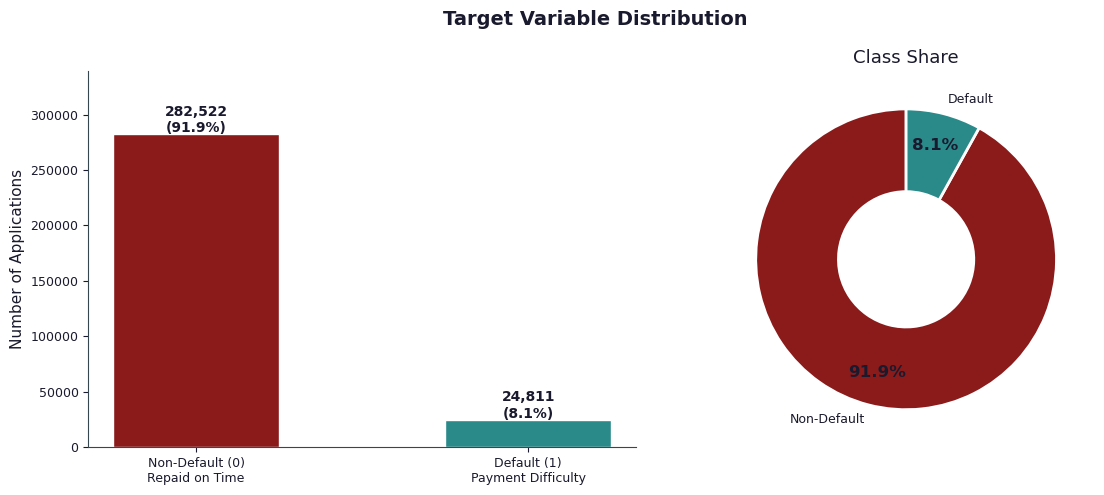

In [516]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Target Variable Distribution", fontsize=14, fontweight="bold", color=NAVY)

labels = ["Non-Default (0)\nRepaid on Time", "Default (1)\nPayment Difficulty"]
bars = axes[0].bar(labels, target_counts.values, color=PALETTE_2, width=0.5, edgecolor="white")
axes[0].set_ylabel("Number of Applications")
for bar, cnt, pct in zip(bars, target_counts.values, target_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, cnt + 2000,
                 f"{cnt:,}\n({pct:.1f}%)", ha="center", fontsize=10, fontweight="bold")
axes[0].set_ylim(0, target_counts.max() * 1.2)

wedges, texts, autotexts = axes[1].pie(
    target_counts.values, labels=["Non-Default", "Default"],
    autopct="%1.1f%%", colors=PALETTE_2, startangle=90, pctdistance=0.78,
    wedgeprops=dict(width=0.55, edgecolor="white", linewidth=2)
)
for at in autotexts:
    at.set_fontsize(12); at.set_fontweight("bold")
axes[1].set_title("Class Share")

plt.tight_layout()
save(fig, "01_target_distribution.png")

### income vs default

In [517]:
income_band= pd.qcut(train['AMT_INCOME_TOTAL'],q=10,duplicates='drop')
income_default= train.groupby(income_band,observed=False)['TARGET'].mean().mul(100)
income_default.index = [
    f"{millify(i.left)} - {millify(i.right)}"
    for i in income_default.index
]

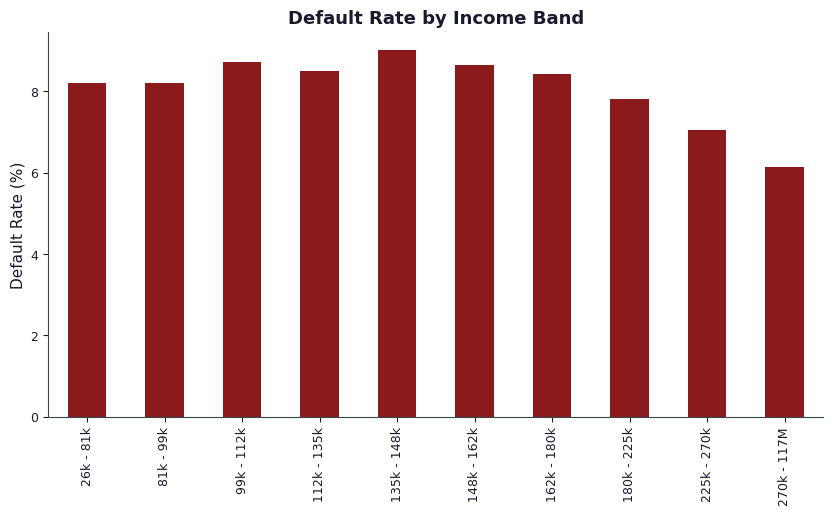

In [518]:
fig, ax = plt.subplots(figsize=(10,5))

income_default.plot(
    kind='bar',
    color=BLUE,
    ax=ax
)

ax.set_title(
    'Default Rate by Income Band',
    color=TITLE,
    fontweight='bold'
)

ax.set_ylabel('Default Rate (%)')

save(fig,'02_income_default.png')

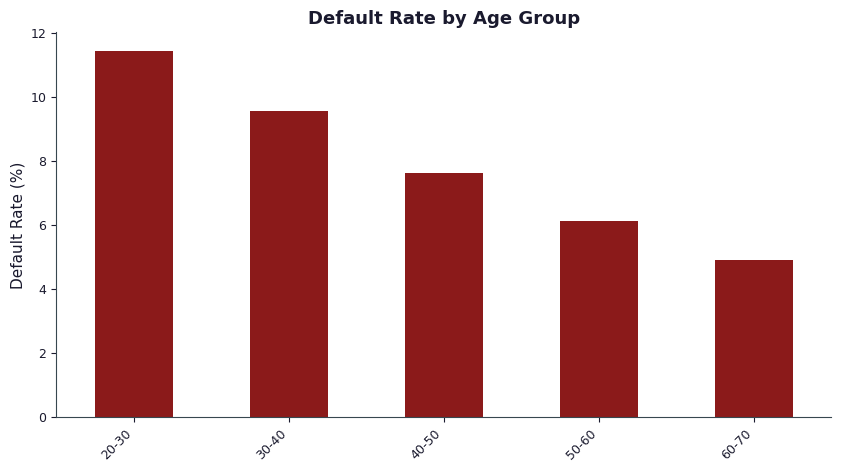

In [519]:
### age vs default
age_group = pd.cut(abs(train['DAYS_BIRTH'])/365, 
                   bins=[20,30,40,50,60,70],
                   include_lowest=True
)
age_default= train.groupby(age_group,observed=False)['TARGET'].mean().mul(100)
age_default.index= [f"{i.left:.0f}-{i.right:.0f}" for i in age_default.index]

fig, ax = plt.subplots(figsize=(10,5))
age_default.plot(
    kind='bar',
    color=BLUE,
    ax=ax
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha= 'right')
ax.set_title(
    'Default Rate by Age Group',
    color=TITLE,
    fontweight='bold'
)

ax.set_ylabel('Default Rate (%)')
save(fig,'03_age_default.png')

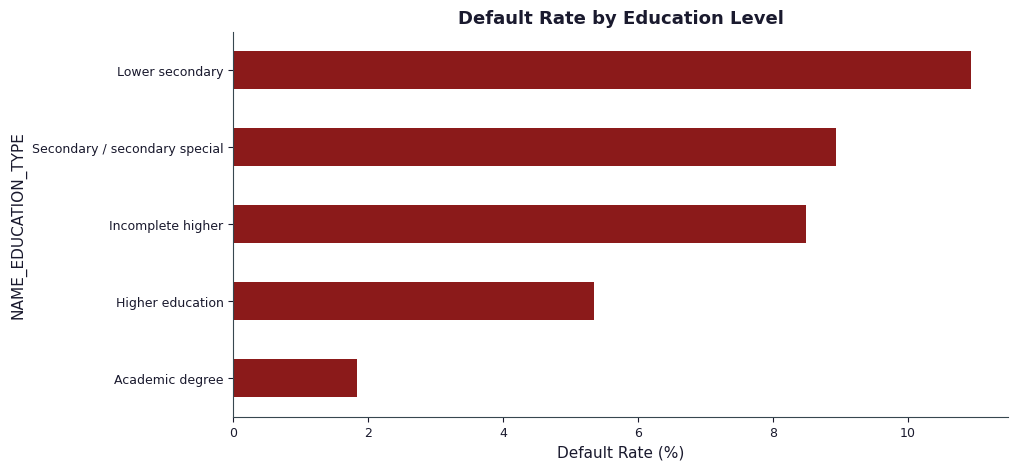

In [520]:
edu_default= train.groupby('NAME_EDUCATION_TYPE',observed=False)['TARGET'].mean().mul(100).sort_values()
fig, ax = plt.subplots(figsize=(10,5))
edu_default.plot(
    kind='barh',
    color=BLUE,
    ax=ax
)
ax.set_title(
    'Default Rate by Education Level',
    color=TITLE,
    fontweight='bold'
)
ax.set_xlabel('Default Rate (%)')
save(fig,'04_education_default.png')

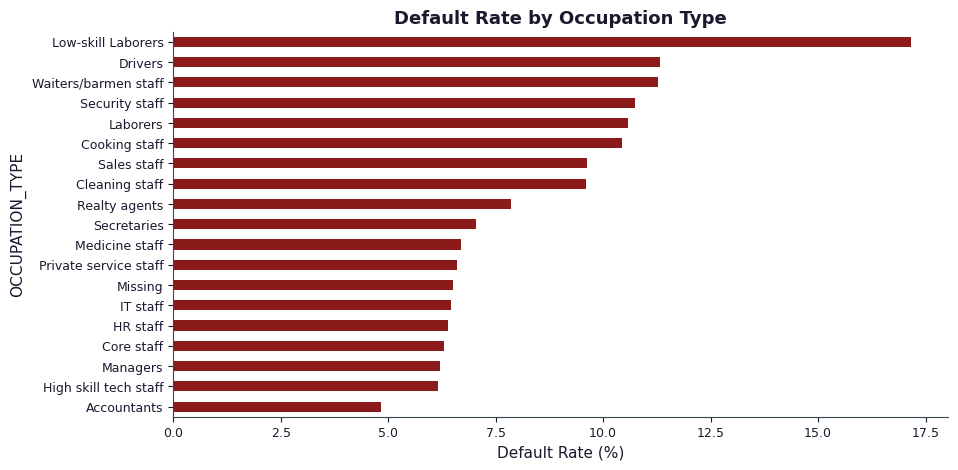

In [521]:
occ_default= train.groupby('OCCUPATION_TYPE',observed=False)['TARGET'].mean().mul(100).sort_values()
fig, ax = plt.subplots(figsize=(10,5))
occ_default.plot(
    kind='barh',
    color=BLUE,
    ax=ax
)   
ax.set_title(
    'Default Rate by Occupation Type',
    color=TITLE,
    fontweight='bold'
)
ax.set_xlabel('Default Rate (%)')
save(fig,'05_occupation_default.png')

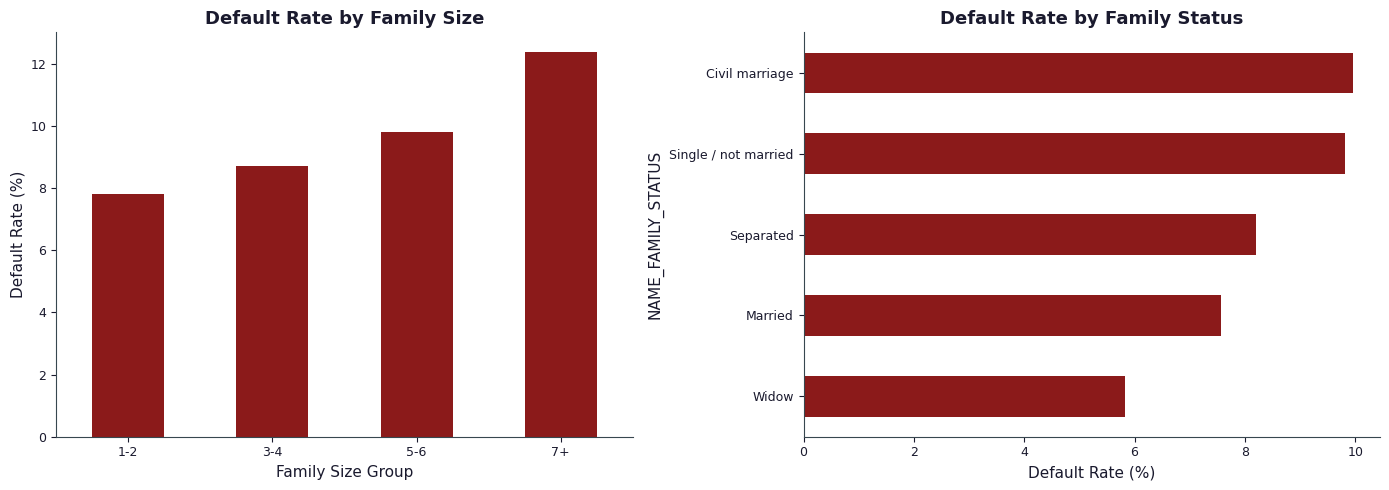

In [522]:
family_default = (
    train.groupby(
        pd.cut(
            train['CNT_FAM_MEMBERS'],
            bins=[0, 2, 4, 6, np.inf],
            labels=['1-2', '3-4', '5-6', '7+']
        ),
        observed=False
    )['TARGET']
    .mean()
    .mul(100)
)
family_status_default = (
    train.groupby('NAME_FAMILY_STATUS', observed=False)['TARGET']
         .mean()
         .mul(100)
         .sort_values()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
family_default.plot(
    kind='bar',
    color=BLUE,
    ax=axes[0]
)
axes[0].set_title(
    'Default Rate by Family Size',
    color=TITLE,
    fontweight='bold'
)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0, ha='center')
axes[0].set_xlabel('Family Size Group')
axes[0].set_ylabel('Default Rate (%)')
family_status_default.plot(
    kind='barh',
    color=BLUE,
    ax=axes[1]
)
axes[1].set_title(
    'Default Rate by Family Status',
    color=TITLE,
    fontweight='bold'
)
axes[1].set_xlabel('Default Rate (%)')
fig.tight_layout()
save(fig,'06_family_default.png')

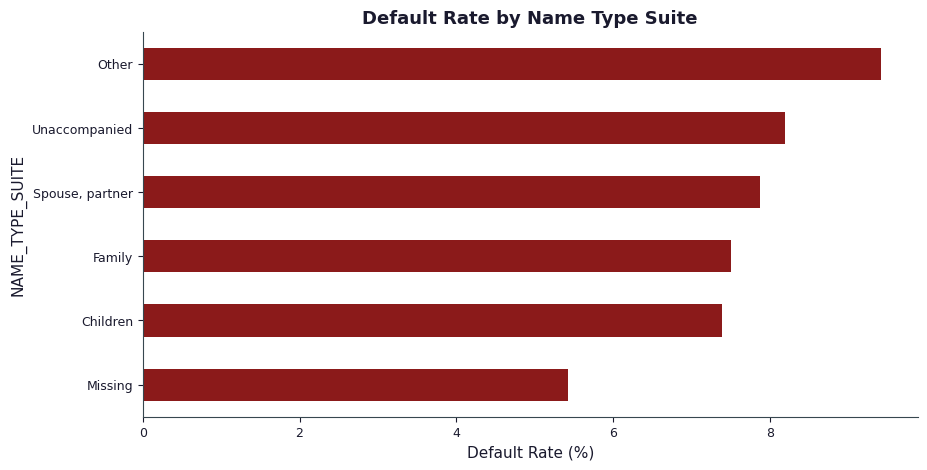

In [523]:
# default rate by name type suite
suite_default = train.groupby('NAME_TYPE_SUITE', observed=False)['TARGET'].mean().mul(100).sort_values()
fig, ax = plt.subplots(figsize=(10,5))
suite_default.plot(
    kind='barh',
    color=BLUE,
    ax=ax
)
ax.set_title(
    'Default Rate by Name Type Suite',
    color=TITLE,
    fontweight='bold'
)
ax.set_xlabel('Default Rate (%)')
save(fig,'07_suite_default.png')

In [524]:
train.NAME_TYPE_SUITE.value_counts(dropna=False)

NAME_TYPE_SUITE
Unaccompanied      248390
Family              40125
Spouse, partner     11362
Children             3265
Other                2901
Missing              1290
Name: count, dtype: int64

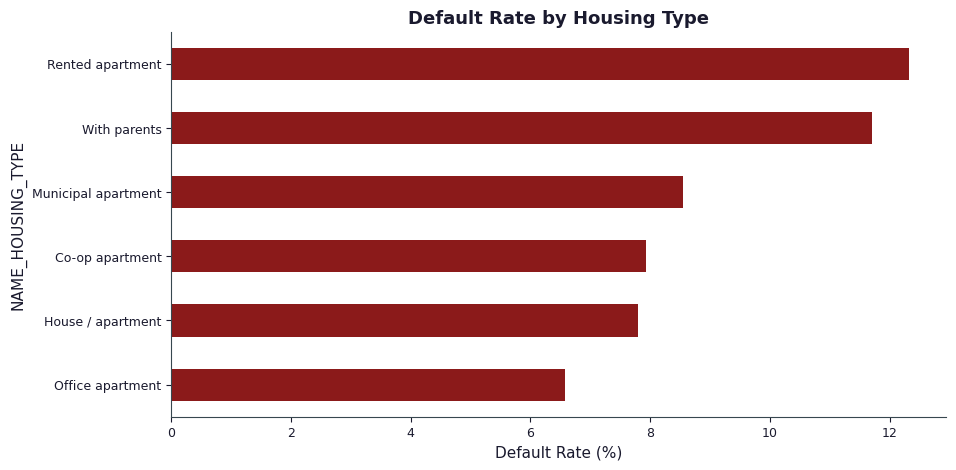

In [525]:
### default rate by housing type
housing_default = (
    train.groupby(
        'NAME_HOUSING_TYPE'
    )['TARGET']
    .mean()
    .mul(100).sort_values()
)
fig, ax = plt.subplots(figsize=(10,5))
housing_default.plot(
    kind='barh',
    color=BLUE,
    ax=ax
)
ax.set_title(
    'Default Rate by Housing Type',
    color=TITLE,
    fontweight='bold'
)
ax.set_xlabel('Default Rate (%)')
save(fig,'08_housing_default.png')

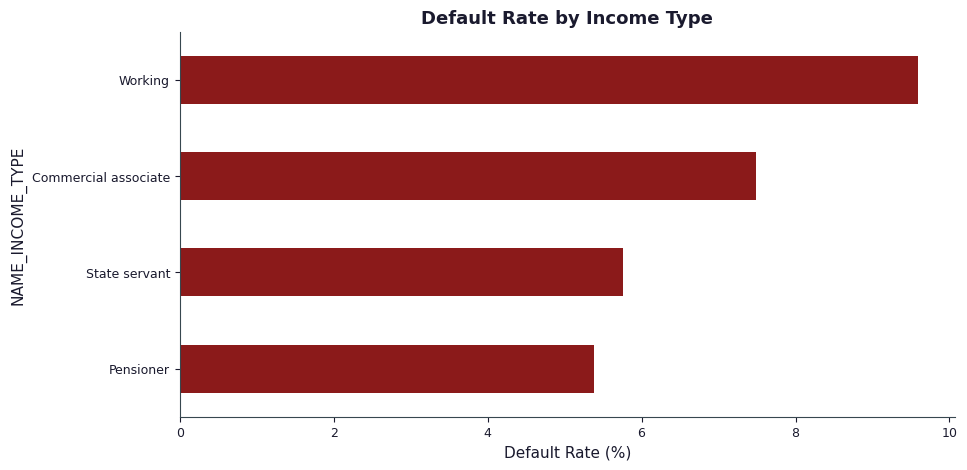

In [526]:
### default rate by income type
income_type_default = (
    train[train['NAME_INCOME_TYPE']!='Other'].groupby('NAME_INCOME_TYPE', observed=False)['TARGET']
         .mean()
         .mul(100)
         .sort_values()
)  
fig, ax = plt.subplots(figsize=(10,5))
income_type_default.plot(
    kind='barh',
    color=BLUE,
    ax=ax
)
ax.set_title(
    'Default Rate by Income Type',
    color=TITLE,
    fontweight='bold'
)
ax.set_xlabel('Default Rate (%)')
save(fig,'09_income_type_default.png')

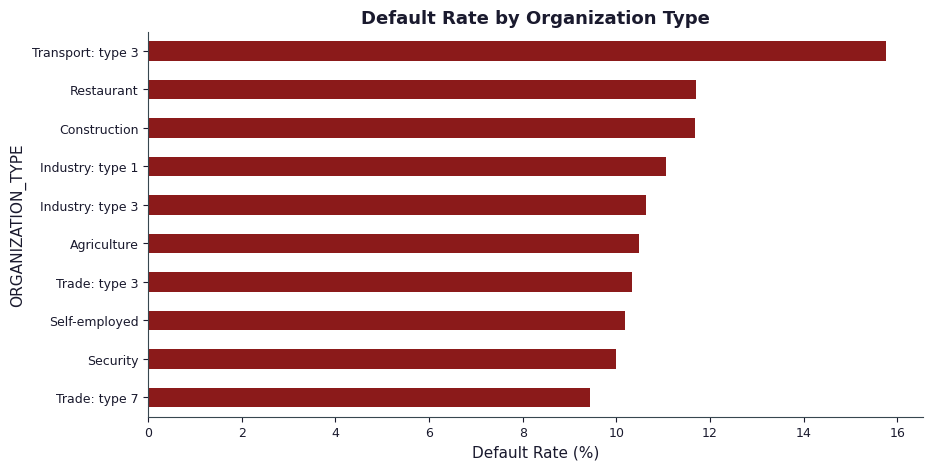

In [527]:
### default rate by organization type
org_summary= (train.groupby('ORGANIZATION_TYPE').agg(
    Count=('TARGET','count'), 
    Default_Rate = ('TARGET',lambda x: x.mean()*100)))
org_default = org_summary[org_summary['Count']>1000].nlargest(10,'Default_Rate').sort_values('Default_Rate')
fig, ax = plt.subplots(figsize=(10,5))
org_default['Default_Rate'].plot(
    kind='barh',
    color=BLUE,
    ax=ax
)
ax.set_title(
    'Default Rate by Organization Type',
    color=TITLE,
    fontweight='bold'
)
ax.set_xlabel('Default Rate (%)')
save(fig,'10_organization_default.png')

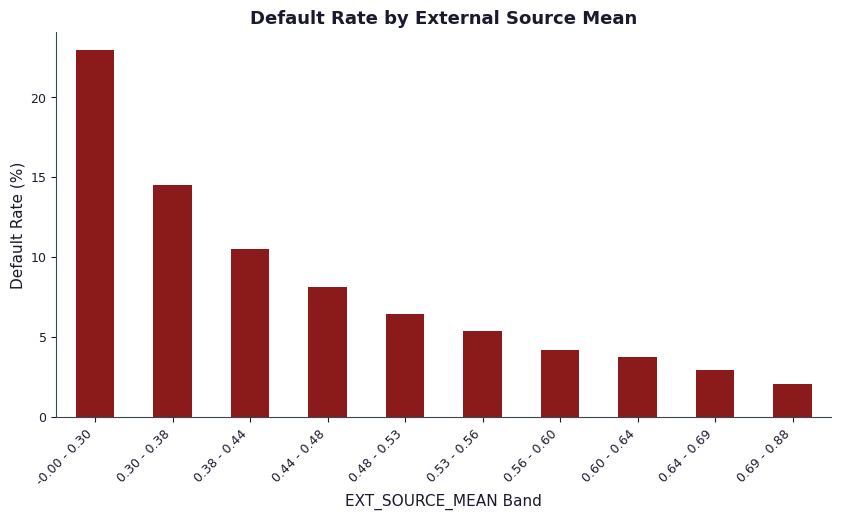

In [528]:
### default rate by external source mean
risk_band= pd.qcut(train['EXT_SOURCE_MEAN'], q=10, duplicates='drop')
risk_default= train.groupby(risk_band, observed=False)['TARGET'].mean().mul(100)
risk_default.index = [f"{i.left:.2f} - {i.right:.2f}" for i in risk_default.index]
fig, ax = plt.subplots(figsize=(10,5))
risk_default.plot(
    kind='bar',
    color=BLUE,
    ax=ax
)
ax.set_title(
    'Default Rate by External Source Mean',
    color=TITLE,
    fontweight='bold'
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_xlabel('EXT_SOURCE_MEAN Band')
ax.set_ylabel('Default Rate (%)')
save(fig,'11_ext_source_default.png')

In [529]:
# corr with the target
corr = train.select_dtypes('number').corr()['TARGET'].sort_values()
display(corr.head(15))
display(corr.tail(15))

EXT_SOURCE_MEAN              -0.22
HAS_BUILDING_INFO            -0.04
IS_LOW_RISK_HOUSETYPE        -0.04
AMT_GOODS_PRICE              -0.04
REGION_POPULATION_RELATIVE   -0.04
AMT_CREDIT                   -0.03
HOUR_APPR_PROCESS_START      -0.02
FLAG_PHONE                   -0.02
AMT_REQ_CREDIT_BUREAU_MON    -0.01
AMT_ANNUITY                  -0.01
LOAN_TO_INCOME               -0.01
AMT_REQ_CREDIT_BUREAU_QRT    -0.01
AMT_INCOME_TOTAL             -0.00
SK_ID_CURR                   -0.00
FLAG_EMAIL                   -0.00
Name: TARGET, dtype: float64

DEF_30_CNT_SOCIAL_CIRCLE      0.03
LIVE_CITY_NOT_WORK_CITY       0.03
DAYS_REGISTRATION             0.04
IS_HIGH_RISK_BUILDING         0.04
WALL_RISK                     0.04
REG_CITY_NOT_LIVE_CITY        0.04
FLAG_EMP_PHONE                0.05
DAYS_EMPLOYED                 0.05
REG_CITY_NOT_WORK_CITY        0.05
DAYS_ID_PUBLISH               0.05
DAYS_LAST_PHONE_CHANGE        0.06
REGION_RATING_CLIENT          0.06
REGION_RATING_CLIENT_W_CITY   0.06
DAYS_BIRTH                    0.08
TARGET                        1.00
Name: TARGET, dtype: float64

### Financial Analysis

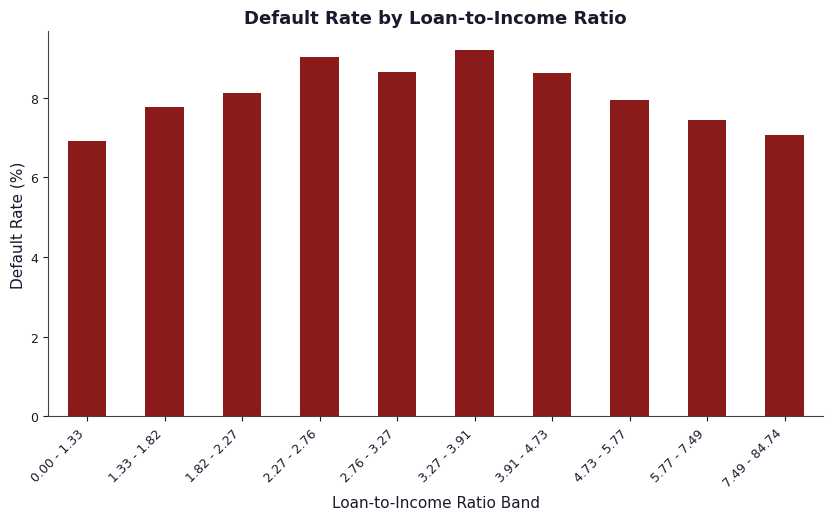

In [530]:
## loan to income ratio vs default
lti_band = pd.qcut(train['LOAN_TO_INCOME'], q=10, duplicates='drop')
lti_default = train.groupby(lti_band, observed=False)['TARGET'].mean().mul(100)
lti_default.index = [f"{i.left:.2f} - {i.right:.2f}" for i in lti_default.index]
fig, ax = plt.subplots(figsize=(10,5))
lti_default.plot(
    kind='bar',
    color=BLUE,
    ax=ax
)
ax.set_title(
    'Default Rate by Loan-to-Income Ratio',
    color=TITLE,
    fontweight='bold'
)   
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_xlabel('Loan-to-Income Ratio Band')
ax.set_ylabel('Default Rate (%)')
save(fig,'12_lti_default.png')

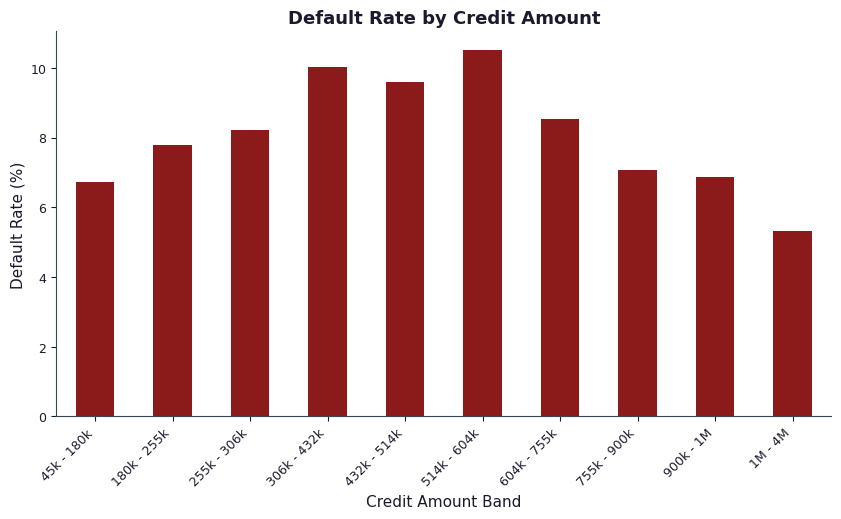

In [531]:
### credit amount vs default
credit_band = pd.qcut(train['AMT_CREDIT'], q=10, duplicates='drop')
credit_default = train.groupby(credit_band, observed=False)['TARGET'].mean().mul(100)
credit_default.index = [f"{millify(i.left)} - {millify(i.right)}" for i in credit_default.index]
fig, ax = plt.subplots(figsize=(10,5))
credit_default.plot(
    kind='bar',
    color=BLUE,
    ax=ax
)
ax.set_title(
    'Default Rate by Credit Amount',
    color=TITLE,
    fontweight='bold'
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_xlabel('Credit Amount Band')
ax.set_ylabel('Default Rate (%)')
save(fig,'13_credit_default.png')

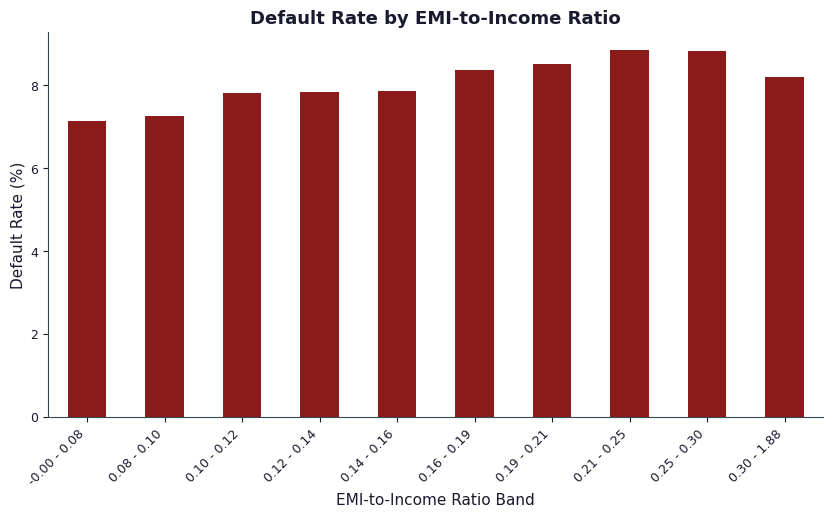

In [532]:
### emi to income ratio vs default
emi_band = pd.qcut(train['AMT_ANNUITY']/train['AMT_INCOME_TOTAL'], q=10, duplicates='drop')
emi_default = train.groupby(emi_band, observed=False)['TARGET'].mean().mul(100)
emi_default.index = [f"{i.left:.2f} - {i.right:.2f}" for i in emi_default.index]
fig, ax = plt.subplots(figsize=(10,5))
emi_default.plot(
    kind='bar',
    color=BLUE,
    ax=ax
)
ax.set_title(
    'Default Rate by EMI-to-Income Ratio',
    color=TITLE,
    fontweight='bold'
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_xlabel('EMI-to-Income Ratio Band')
ax.set_ylabel('Default Rate (%)')
save(fig,'14_emi_default.png')

In [533]:
train.groupby(emi_band).agg(
    Count=('TARGET','count'),
    Default_Rate=('TARGET', lambda x: x.mean()*100)
)

C:\Users\stylo\AppData\Local\Temp\ipykernel_31284\1371832299.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train.groupby(emi_band).agg(


,Count,Default_Rate
"(-0.000776, 0.08]",31629,7.14
"(0.08, 0.104]",29839,7.27
"(0.104, 0.125]",30736,7.81
"(0.125, 0.144]",30738,7.85
"(0.144, 0.163]",30738,7.88
"(0.163, 0.186]",30726,8.38
"(0.186, 0.212]",30740,8.53
"(0.212, 0.247]",30735,8.85
"(0.247, 0.302]",30719,8.84
"(0.302, 1.876]",30733,8.20


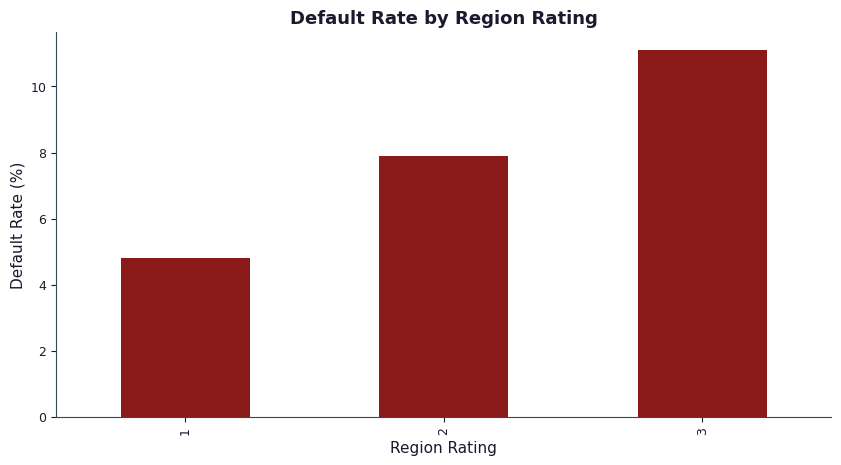

In [534]:
### region rating vs default
region_default = train.groupby('REGION_RATING_CLIENT', observed=False)['TARGET'].mean().mul(100)
fig, ax = plt.subplots(figsize=(10,5))
region_default.plot(
    kind='bar',
    color=BLUE,
    ax=ax
)
ax.set_title(
    'Default Rate by Region Rating',
    color=TITLE,
    fontweight='bold'
)   
ax.set_xlabel('Region Rating')
ax.set_ylabel('Default Rate (%)')
save(fig,'15_region_default.png')

In [535]:
train.columns[train.columns.str.contains('REGION_RATING')]

Index(['REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY'], dtype='object')

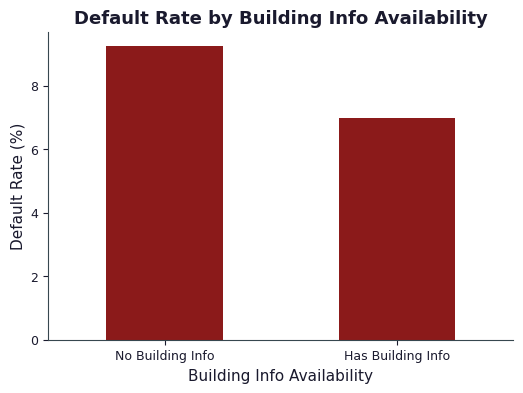

In [536]:
# has building info vs default
building_default = train.groupby('HAS_BUILDING_INFO', observed=False)['TARGET'].mean().mul(100)
fig, ax = plt.subplots(figsize=(6,4))
building_default.plot(
    kind='bar',
    color=BLUE,
    ax=ax
)
ax.set_title(
    'Default Rate by Building Info Availability',
    color=TITLE,
    fontweight='bold'
)
ax.set_xticklabels(['No Building Info', 'Has Building Info'], rotation=0)
ax.set_xlabel('Building Info Availability')
ax.set_ylabel('Default Rate (%)')
save(fig,'16_building_info_default.png')

C:\Users\stylo\AppData\Local\Temp\ipykernel_31284\209126958.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


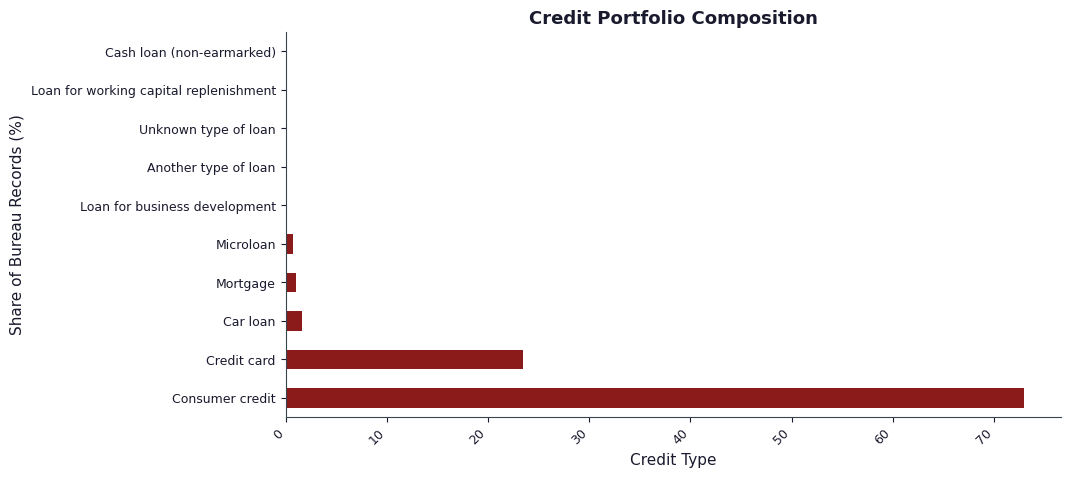

In [537]:
### Existing credit portfolio composition
credit_mix = (
    bureau['CREDIT_TYPE']
    .value_counts(normalize=True)
    .mul(100)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10,5))

credit_mix.plot(
    kind='barh',
    color=BLUE,
    ax=ax
)

ax.set_title(
    'Credit Portfolio Composition',
    color=TITLE,
    fontweight='bold'
)

ax.set_xlabel('Credit Type')
ax.set_ylabel('Share of Bureau Records (%)')

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha='right'
)

save(fig,'17_credit_portfolio_mix.png')

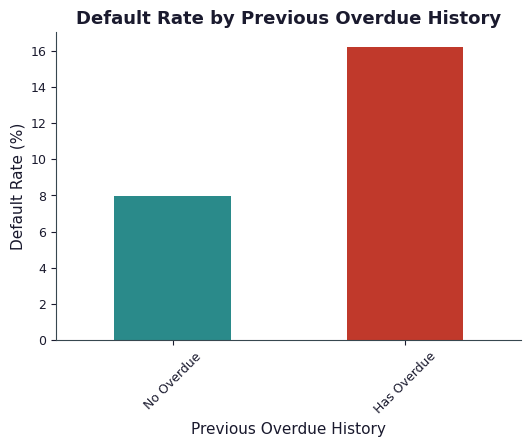

In [538]:
### previous overdue history vs default
bureau_overdue = (
    bureau.groupby('SK_ID_CURR', as_index=False)
    ['AMT_CREDIT_SUM_OVERDUE']
    .max()
)

bureau_overdue['HAS_OVERDUE'] = (
    bureau_overdue['AMT_CREDIT_SUM_OVERDUE'] > 0
).astype(int)
temp = train[
    ['SK_ID_CURR','TARGET']
].merge(
    bureau_overdue[
        ['SK_ID_CURR','HAS_OVERDUE']
    ],
    on='SK_ID_CURR',
    how='left'
)

temp['HAS_OVERDUE'] = (
    temp['HAS_OVERDUE']
    .fillna(0)
)
overdue_default = (
    temp.groupby('HAS_OVERDUE')
    ['TARGET']
    .mean()
    .mul(100)
)

fig, ax = plt.subplots(figsize=(6,4))

overdue_default.plot(
    kind='bar',
    color=[MINT,CORAL],
    ax=ax
)

ax.set_title(
    'Default Rate by Previous Overdue History',
    color=TITLE,
    fontweight='bold'
)

ax.set_xlabel('Previous Overdue History')
ax.set_ylabel('Default Rate (%)')

ax.set_xticklabels([
    'No Overdue',
    'Has Overdue'
],rotation=45)
save(fig,'18_overdue_history_default.png')

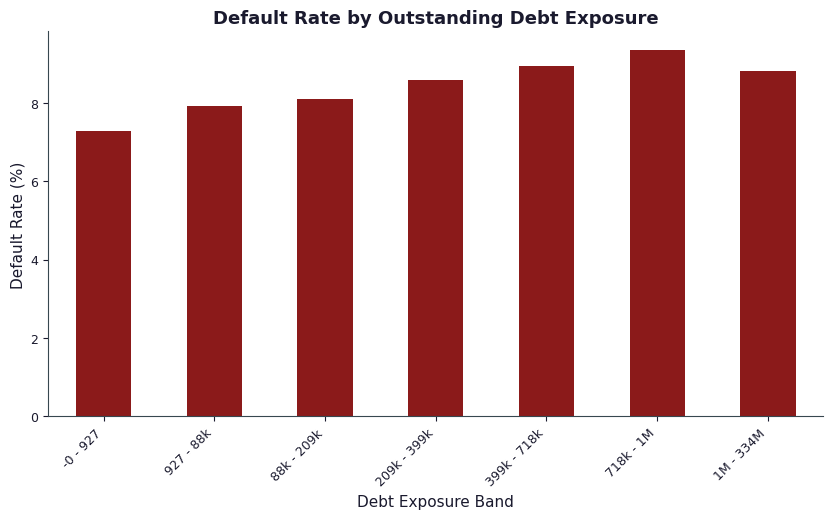

In [539]:
### debt exposure vs default
cust_debt = (
    bureau.groupby('SK_ID_CURR')
    ['AMT_CREDIT_SUM_DEBT']
    .sum()
    .reset_index()
)
temp = train[
    ['SK_ID_CURR','TARGET']
].merge(
    cust_debt,
    on='SK_ID_CURR',
    how='left'
)

temp['AMT_CREDIT_SUM_DEBT'] = (
    temp['AMT_CREDIT_SUM_DEBT']
    .fillna(0)
)
debt_band = pd.qcut(
    temp['AMT_CREDIT_SUM_DEBT'],
    q=10,
    duplicates='drop'
)

debt_default = (
    temp.groupby(
        debt_band,
        observed=False
    )['TARGET']
    .mean()
    .mul(100)
)
debt_default.index = [
    f"{millify(i.left)} - {millify(i.right)}"
    for i in debt_default.index
]
fig, ax = plt.subplots(figsize=(10,5))

debt_default.plot(
    kind='bar',
    color=BLUE,
    ax=ax
)

ax.set_title(
    'Default Rate by Outstanding Debt Exposure',
    color=TITLE,
    fontweight='bold'
)

ax.set_xlabel('Debt Exposure Band')
ax.set_ylabel('Default Rate (%)')

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha='right'
)

save(fig,'19_debt_exposure_default.png')

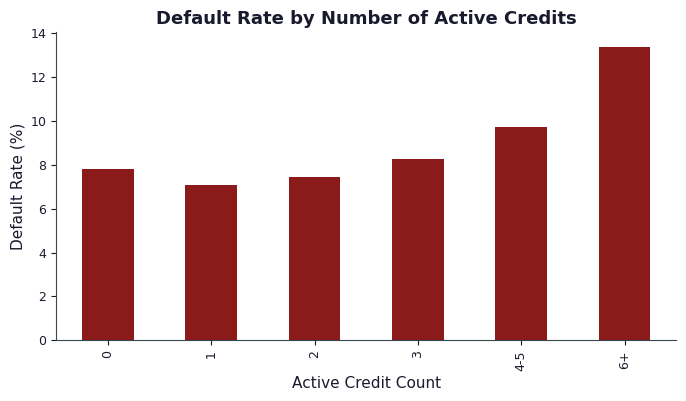

In [540]:
### active credit count vs default
active_cnt = (
    bureau[
        bureau['CREDIT_ACTIVE']=='Active'
    ]
    .groupby('SK_ID_CURR')
    .size()
    .reset_index(name='ACTIVE_CREDIT_CNT')
)
temp = train[
    ['SK_ID_CURR','TARGET']
].merge(
    active_cnt,
    on='SK_ID_CURR',
    how='left'
)

temp['ACTIVE_CREDIT_CNT'] = (
    temp['ACTIVE_CREDIT_CNT']
    .fillna(0)
)
credit_band = pd.cut(
    temp['ACTIVE_CREDIT_CNT'],
    bins=[-1,0,1,2,3,5,100],
    labels=[
        '0',
        '1',
        '2',
        '3',
        '4-5',
        '6+'
    ]
)

credit_default = (
    temp.groupby(
        credit_band,
        observed=False
    )['TARGET']
    .mean()
    .mul(100)
)
fig, ax = plt.subplots(figsize=(8,4))

credit_default.plot(
    kind='bar',
    color=BLUE,
    ax=ax
)

ax.set_title(
    'Default Rate by Number of Active Credits',
    color=TITLE,
    fontweight='bold'
)

ax.set_xlabel('Active Credit Count')
ax.set_ylabel('Default Rate (%)')

save(fig,'20_active_credit_default.png')


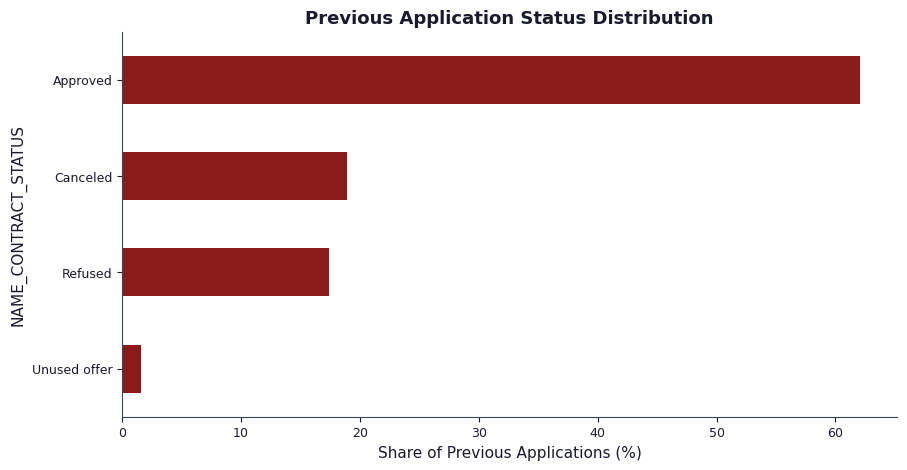

In [541]:
### previous application distribution vs default
prev_status=(prev['NAME_CONTRACT_STATUS'].value_counts(normalize=True)*100).sort_values()
fig, ax = plt.subplots(figsize=(10,5))
prev_status.plot(
    kind='barh',
    color=BLUE,
    ax=ax
)   
ax.set_title(
    'Previous Application Status Distribution',
    color=TITLE,
    fontweight='bold'
)
ax.set_xlabel('Share of Previous Applications (%)')
save(fig,'21_previous_application_status.png')

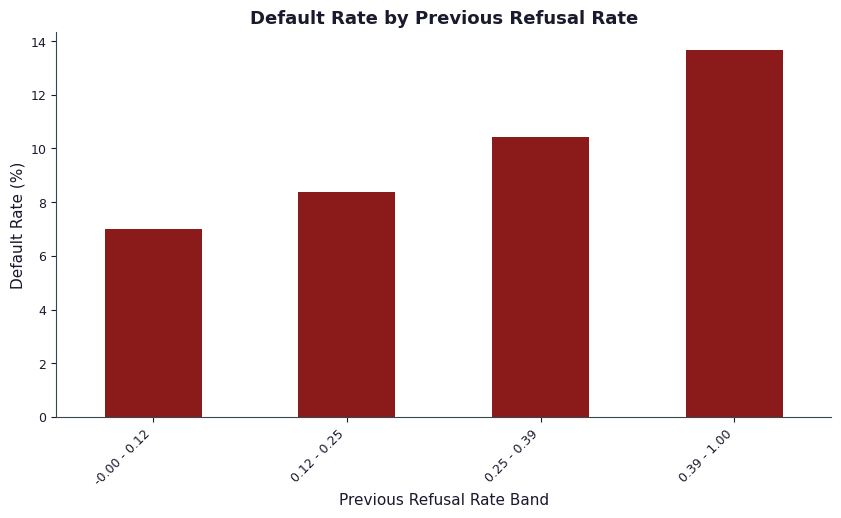

In [542]:
### Previous Refusal Rate vs Current Default
refusal_rate = (prev.assign(Is_Refused=(
    prev['NAME_CONTRACT_STATUS'].eq('Refused').astype(int))
    )
).groupby('SK_ID_CURR', as_index=False).agg(TOTAL_APPLICATIONS=('SK_ID_PREV','count'),
                                            REFUSED_APPLICATIONS=('Is_Refused','sum'))
refusal_rate['REFUSAL_RATE'] = refusal_rate['REFUSED_APPLICATIONS'] / refusal_rate['TOTAL_APPLICATIONS']
temp = train[
    ['SK_ID_CURR','TARGET']
].merge(
    refusal_rate[['SK_ID_CURR','REFUSAL_RATE']],
    on='SK_ID_CURR',
    how='left'
)
temp['REFUSAL_RATE'] = temp['REFUSAL_RATE'].fillna(0)
refusal_band = pd.qcut(temp['REFUSAL_RATE'], q=10, duplicates='drop')
refusal_default = (
    temp.groupby(
        refusal_band,
        observed=False
    )['TARGET']
    .mean()
    .mul(100)
)
refusal_default.index = [
    f"{i.left:.2f} - {i.right:.2f}"
    for i in refusal_default.index
]
fig, ax = plt.subplots(figsize=(10,5))
refusal_default.plot(
    kind='bar',
    color=BLUE,
    ax=ax
)
ax.set_title(
    'Default Rate by Previous Refusal Rate',
    color=TITLE,
    fontweight='bold'
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha='right'
)
ax.set_xlabel('Previous Refusal Rate Band')
ax.set_ylabel('Default Rate (%)')
save(fig,'22_previous_refusal_rate_default.png')

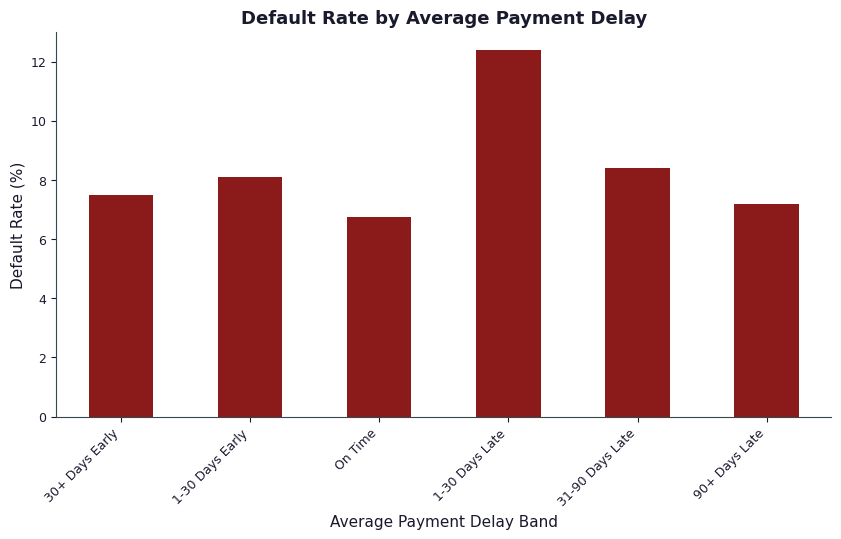

In [543]:
### payment delay vs default
ip['PAYMENT_DELAY'] = ip['DAYS_ENTRY_PAYMENT'] - ip['DAYS_INSTALMENT']
cust_delay= (
    ip.groupby('SK_ID_CURR', as_index=False)
    .agg(AVG_PAYMENT_DELAY=('PAYMENT_DELAY','mean'))
)
temp = train[
    ['SK_ID_CURR','TARGET']].merge(
    cust_delay,
    on='SK_ID_CURR',
    how='left'
)
temp['AVG_PAYMENT_DELAY'] = temp['AVG_PAYMENT_DELAY'].fillna(0)
delay_band = pd.cut(
    temp['AVG_PAYMENT_DELAY'],
    bins=[-10000,-30,-1,0,30,90,10000],
    labels=[
        '30+ Days Early',
        '1-30 Days Early',
        'On Time',
        '1-30 Days Late',
        '31-90 Days Late',
        '90+ Days Late'
    ]
)
delay_default = (
    temp.groupby(
        delay_band,
        observed=False
    )['TARGET']
    .mean()
    .mul(100)
)
fig, ax = plt.subplots(figsize=(10,5))
delay_default.plot(
    kind='bar',
    color=BLUE,
    ax=ax
)
ax.set_title(
    'Default Rate by Average Payment Delay',
    color=TITLE,
    fontweight='bold'
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha='right'
)
ax.set_xlabel('Average Payment Delay Band')
ax.set_ylabel('Default Rate (%)')
save(fig,'23_payment_delay_default.png')

In [544]:
# =========================================
# STATUS NUMERIC MAPPING
# =========================================

status_map = {
    '0':0,
    '1':1,
    '2':2,
    '3':3,
    '4':4,
    '5':5
}

bb['STATUS_NUM'] = (bb['STATUS'].map(status_map))
# =========================================
# BUREAU BALANCE FEATURE ENGINEERING
# =========================================

# Payment delay flags
bb['HAS_DPD'] = (bb['STATUS'].isin(['1', '2', '3', '4', '5']).astype(int))

# Severe delay flags
bb['SEVERE_DPD'] = (bb['STATUS'].isin(['3', '4', '5']).astype(int))

# Loan closed flag
bb['IS_CLOSED'] = ((bb['STATUS'] == 'C').astype(int))

# =========================================
# LOAN LEVEL AGGREGATION
# 1 row = 1 SK_ID_BUREAU
# =========================================

bb_loan_agg = bb.groupby('SK_ID_BUREAU').agg(
    # Loan level Status
     MAX_STATUS = ('STATUS_NUM','max'),
     MEAN_STATUS = ('STATUS_NUM','mean'),
    # Any delay history
    HAS_DPD_HISTORY = ('HAS_DPD','max'),
    # % months delayed
    DPD_RATIO = ('HAS_DPD','mean'),
    # % severe delinquency
    SEVERE_DPD_RATIO = ('SEVERE_DPD','mean'),
    # Loan closed frequency
    CLOSED_RATIO = ('IS_CLOSED','mean'),
    # Credit history length
    MONTHS_BALANCE_MIN = ('MONTHS_BALANCE','min'),
    MONTHS_BALANCE_MAX = ('MONTHS_BALANCE','max'),
    MONTHS_COUNT = ('MONTHS_BALANCE','count')
).reset_index()

In [545]:
# =========================================
# Merging to bureau 
# 1 row = 1 bureau loan record, enriched with balance history features
# =========================================
bureau = bureau.merge(
    bb_loan_agg,
    on='SK_ID_BUREAU',
    how='left'
)

In [546]:
check=bureau.head().T
check['missing%']=bureau.isna().mean().mul(100)
check.sort_values(by='missing%',ascending=False)

,0,1,2,3,4,missing%
MEAN_STATUS,NaN,NaN,NaN,NaN,NaN,61.35
MAX_STATUS,NaN,NaN,NaN,NaN,NaN,61.35
MONTHS_BALANCE_MAX,NaN,NaN,NaN,NaN,NaN,54.89
MONTHS_BALANCE_MIN,NaN,NaN,NaN,NaN,NaN,54.89
CLOSED_RATIO,NaN,NaN,NaN,NaN,NaN,54.89
HAS_DPD_HISTORY,NaN,NaN,NaN,NaN,NaN,54.89
DPD_RATIO,NaN,NaN,NaN,NaN,NaN,54.89
SEVERE_DPD_RATIO,NaN,NaN,NaN,NaN,NaN,54.89
MONTHS_COUNT,NaN,NaN,NaN,NaN,NaN,54.89
SK_ID_CURR,215354,215354,215354,215354,215354,0.00


In [547]:
# =========================================
# BUREAU CUSTOMER LEVEL AGGREGATION
# =========================================

bureau_agg = bureau.groupby('SK_ID_CURR').agg(
    # =========================================
    # CUSTOMER LEVEL AGGREGATION
    # =========================================

    MAX_BUREAU_STATUS = ('MAX_STATUS','max'),
    AVG_BUREAU_STATUS = ('MEAN_STATUS','mean'),
    # =====================================
    # CREDIT COUNTS
    # =====================================

    TOTAL_BUREAU_LOANS = ('SK_ID_BUREAU','count'),

    ACTIVE_CREDIT_COUNT = ('CREDIT_ACTIVE',lambda x: (x == 'Active').sum()),
    CLOSED_CREDIT_COUNT = ('CREDIT_ACTIVE',lambda x: (x == 'Closed').sum()),

    # =====================================
    # DEBT FEATURES
    # =====================================

    TOTAL_DEBT = ('AMT_CREDIT_SUM_DEBT','sum'),
    AVG_DEBT = ('AMT_CREDIT_SUM_DEBT','mean'),

    MAX_DEBT = ('AMT_CREDIT_SUM_DEBT','max'),

    # =====================================
    # CREDIT AMOUNT FEATURES
    # =====================================

    TOTAL_CREDIT_SUM = ('AMT_CREDIT_SUM','sum'),
    AVG_CREDIT_SUM = ('AMT_CREDIT_SUM','mean'),
    MAX_CREDIT_SUM = ('AMT_CREDIT_SUM','max'),

    # =====================================
    # OVERDUE FEATURES
    # =====================================

    TOTAL_OVERDUE = ('AMT_CREDIT_SUM_OVERDUE','sum'),
    MAX_OVERDUE = ('AMT_CREDIT_SUM_OVERDUE','max'),

    HAS_OVERDUE = ('AMT_CREDIT_SUM_OVERDUE',lambda x: int((x > 0).any())),
    AVG_CREDIT_DAY_OVERDUE = ('CREDIT_DAY_OVERDUE','mean'),
    MAX_CREDIT_DAY_OVERDUE = ('CREDIT_DAY_OVERDUE','max'),

    # =====================================
    # CREDIT TIME FEATURES
    # =====================================

    AVG_DAYS_CREDIT = ('DAYS_CREDIT','mean'),
    MIN_DAYS_CREDIT = ('DAYS_CREDIT','min'),
    MAX_DAYS_CREDIT = ('DAYS_CREDIT','max'),

    AVG_DAYS_CREDIT_ENDDATE = ('DAYS_CREDIT_ENDDATE','mean'),
    AVG_DAYS_CREDIT_UPDATE = ('DAYS_CREDIT_UPDATE','mean'),

    # =====================================
    # BUREAU BALANCE FEATURES
    # =====================================

    HAS_DPD_HISTORY = ('HAS_DPD_HISTORY','max'),
    AVG_DPD_RATIO = ('DPD_RATIO','mean'),

    AVG_SEVERE_DPD_RATIO = ('SEVERE_DPD_RATIO','mean'),
    AVG_CLOSED_RATIO = ('CLOSED_RATIO','mean'),

    AVG_MONTHS_HISTORY = ('MONTHS_COUNT','mean')
).reset_index()

# =========================================
# BUREAU ADVANCED RATIO FEATURES
# =========================================

bureau_agg['ACTIVE_DEBT_RATIO'] = (bureau_agg['TOTAL_DEBT']/bureau_agg['TOTAL_CREDIT_SUM'])

bureau_agg['OVERDUE_TO_CREDIT_RATIO'] = (bureau_agg['TOTAL_OVERDUE']/bureau_agg['TOTAL_CREDIT_SUM'])

bureau_agg['CLOSED_TO_TOTAL_RATIO'] = (bureau_agg['CLOSED_CREDIT_COUNT']/bureau_agg['TOTAL_BUREAU_LOANS'])

bureau_agg['OVERDUE_PER_ACTIVE_LOAN'] = (bureau_agg['TOTAL_OVERDUE']/(bureau_agg['ACTIVE_CREDIT_COUNT'] + 1))

bureau_agg['DEBT_PER_ACTIVE_LOAN'] = (bureau_agg['TOTAL_DEBT']/(bureau_agg['ACTIVE_CREDIT_COUNT'] + 1))


In [548]:
check=prev.head().T
check['missing%']=prev.isna().mean().mul(100)
check.sort_values(by='missing%',ascending=False)

,0,1,2,3,4,missing%
SK_ID_PREV,2030495,2802425,2523466,2819243,1784265,0.00
SK_ID_CURR,271877,108129,122040,176158,202054,0.00
NAME_CONTRACT_TYPE,Consumer loans,Cash loans,Cash loans,Cash loans,Cash loans,0.00
AMT_ANNUITY,1730.43,25188.62,15060.74,47041.33,31924.40,0.00
AMT_APPLICATION,17145.00,607500.00,112500.00,450000.00,337500.00,0.00
AMT_CREDIT,17145.00,679671.00,136444.50,470790.00,404055.00,0.00
AMT_DOWN_PAYMENT,0.00,0.00,0.00,0.00,0.00,0.00
AMT_GOODS_PRICE,17145.00,607500.00,112500.00,450000.00,337500.00,0.00
WEEKDAY_APPR_PROCESS_START,SATURDAY,THURSDAY,TUESDAY,MONDAY,THURSDAY,0.00
HOUR_APPR_PROCESS_START,15,11,11,7,9,0.00


In [549]:
# =========================================
# PREVIOUS APPLICATION AGGREGATION
# =========================================

# Status flags
prev['IS_APPROVED'] = ((prev['NAME_CONTRACT_STATUS'] == 'Approved').astype(int))
prev['IS_REFUSED'] = ((prev['NAME_CONTRACT_STATUS'] == 'Refused').astype(int))
prev['IS_CANCELLED'] = ((prev['NAME_CONTRACT_STATUS'] == 'Canceled').astype(int))

# =========================================
# CUSTOMER LEVEL AGGREGATION
# =========================================

previous_agg = prev.groupby('SK_ID_CURR').agg(

    # =====================================
    # APPLICATION COUNTS
    # =====================================

    TOTAL_PREV_APPLICATIONS = ('SK_ID_PREV','count'),
    APPROVED_COUNT = ('IS_APPROVED','sum'),
    REFUSED_COUNT = ('IS_REFUSED','sum'),
    CANCELLED_COUNT = ('IS_CANCELLED','sum'),

    # =====================================
    # CREDIT FEATURES
    # =====================================

    AVG_PREV_CREDIT = ('AMT_CREDIT','mean'),
    MAX_PREV_CREDIT = ('AMT_CREDIT','max'),
    AVG_PREV_APPLICATION = ('AMT_APPLICATION','mean'),
    AVG_GOODS_PRICE = ('AMT_GOODS_PRICE','mean'),

    # =====================================
    # ANNUITY FEATURES
    # =====================================

    AVG_PREV_ANNUITY = ('AMT_ANNUITY','mean'),
    MAX_PREV_ANNUITY = ('AMT_ANNUITY','max'),

    # =====================================
    # PAYMENT FEATURES
    # =====================================

    AVG_CNT_PAYMENT = ('CNT_PAYMENT','mean'),
    MAX_CNT_PAYMENT = ('CNT_PAYMENT','max'),

    # =====================================
    # TIME FEATURES
    # =====================================

    AVG_DAYS_DECISION = ('DAYS_DECISION','mean'),
    MIN_DAYS_DECISION = ('DAYS_DECISION','min'),
    MAX_DAYS_DECISION = ('DAYS_DECISION','max'),

    # =====================================
    # MISSING FLAGS
    # =====================================

    AVG_DAYS_LAST_DUE_MISSING = ('DAYS_LAST_DUE_MISSING','mean'),
    AVG_INSURED_MISSING = ('INSURED_MISSING','mean')
).reset_index()

In [550]:
check= ip.head().T
check['missing%']=ip.isna().mean().mul(100)
check.sort_values(by='missing%',ascending=False)

,0,1,2,3,4,missing%
SK_ID_PREV,1054186.00,1330831.00,2085231.00,2452527.00,2714724.00,0.00
SK_ID_CURR,161674.00,151639.00,193053.00,199697.00,167756.00,0.00
NUM_INSTALMENT_VERSION,1.00,0.00,2.00,1.00,1.00,0.00
NUM_INSTALMENT_NUMBER,6.00,34.00,1.00,3.00,2.00,0.00
DAYS_INSTALMENT,-1180.00,-2156.00,-63.00,-2418.00,-1383.00,0.00
DAYS_ENTRY_PAYMENT,-1187.00,-2156.00,-63.00,-2426.00,-1366.00,0.00
AMT_INSTALMENT,6948.36,1716.53,25425.00,24350.13,2165.04,0.00
AMT_PAYMENT,6948.36,1716.53,25425.00,24350.13,2160.59,0.00
PAYMENT_DELAY,-7.00,0.00,0.00,-8.00,17.00,0.00


In [551]:
# =========================================
# INSTALLMENTS PAYMENTS FEATURE ENGINEERING
# =========================================

ip['PAYMENT_DELAY'] = (ip['DAYS_ENTRY_PAYMENT']-ip['DAYS_INSTALMENT']).clip(lower=0)
ip['PAYMENT_RATIO'] = (ip['AMT_PAYMENT']/ip['AMT_INSTALMENT'])
ip['LATE_PAYMENT'] = ((ip['PAYMENT_DELAY'] > 0).astype(int))
ip['UNDER_PAYMENT'] = ((ip['PAYMENT_RATIO'] < 1).astype(int))
ip['DPD_OVER_30'] = ((ip['PAYMENT_DELAY'] > 30).astype(int))
ip['DPD_OVER_60'] = ((ip['PAYMENT_DELAY'] > 60).astype(int))
ip['DPD_OVER_90'] = ((ip['PAYMENT_DELAY'] > 90).astype(int))

# =========================================
# CUSTOMER LEVEL AGGREGATION
# =========================================

ip_agg = ip.groupby('SK_ID_CURR').agg(
    TOTAL_INSTALLMENTS = ('SK_ID_PREV','count'),
    AVG_PAYMENT_DELAY = ('PAYMENT_DELAY','mean'),
    STD_PAYMENT_DELAY = ('PAYMENT_DELAY','std'),
    MAX_PAYMENT_DELAY = ('PAYMENT_DELAY','max'),
    AVG_PAYMENT_RATIO = ('PAYMENT_RATIO','mean'),
    MIN_PAYMENT_RATIO = ('PAYMENT_RATIO','min'),
    LATE_PAYMENT_RATIO = ('LATE_PAYMENT','mean'),
    PAYMENT_RATIO_STD = ('PAYMENT_RATIO','std'),
    UNDER_PAYMENT_RATIO = ('UNDER_PAYMENT','mean'),
    AVG_AMT_PAYMENT = ('AMT_PAYMENT','mean'),
    MAX_AMT_PAYMENT = ('AMT_PAYMENT','max'),
    AVG_AMT_INSTALMENT = ('AMT_INSTALMENT','mean'),
    MAX_AMT_INSTALMENT = ('AMT_INSTALMENT','max'),
    AVG_DAYS_INSTALMENT = ('DAYS_INSTALMENT','mean'),
    AVG_DAYS_ENTRY_PAYMENT = ('DAYS_ENTRY_PAYMENT','mean'),
    DPD_OVER_30_MEAN = ('DPD_OVER_30','mean'),
    DPD_OVER_30_MAX = ('DPD_OVER_30','max'),
    DPD_OVER_30_STD = ('DPD_OVER_30','std'),
    DPD_OVER_60_MEAN = ('DPD_OVER_60','mean'),
    DPD_OVER_60_MAX = ('DPD_OVER_60','max'),
    DPD_OVER_60_STD = ('DPD_OVER_60','std'),
    DPD_OVER_90_MEAN = ('DPD_OVER_90','mean'),
    DPD_OVER_90_MAX = ('DPD_OVER_90','max'),
    DPD_OVER_90_STD = ('DPD_OVER_90','std')
).reset_index()

In [552]:
check=cc.head().T
check['missing%']=cc.isna().mean().mul(100)
check.sort_values(by='missing%',ascending=False)

,0,1,2,3,4,missing%
SK_ID_PREV,2562384,2582071,1740877,1389973,1891521,0.00
SK_ID_CURR,378907,363914,371185,337855,126868,0.00
MONTHS_BALANCE,-6,-1,-7,-4,-1,0.00
AMT_BALANCE,56.97,63975.56,31815.22,236572.11,453919.46,0.00
AMT_CREDIT_LIMIT_ACTUAL,135000,45000,450000,225000,450000,0.00
AMT_DRAWINGS_ATM_CURRENT,0.00,2250.00,0.00,2250.00,0.00,0.00
AMT_DRAWINGS_CURRENT,877.50,2250.00,0.00,2250.00,11547.00,0.00
AMT_DRAWINGS_OTHER_CURRENT,0.00,0.00,0.00,0.00,0.00,0.00
AMT_DRAWINGS_POS_CURRENT,877.50,0.00,0.00,0.00,11547.00,0.00
AMT_INST_MIN_REGULARITY,1700.33,2250.00,2250.00,11795.76,22924.89,0.00


In [553]:
# =========================================
# CREDIT CARD FEATURE ENGINEERING
# =========================================

cc['LIMIT_USAGE_RATIO'] = (cc['AMT_BALANCE']/cc['AMT_CREDIT_LIMIT_ACTUAL'])
cc['PAYMENT_RATIO'] = (cc['AMT_PAYMENT_TOTAL_CURRENT']/cc['AMT_INST_MIN_REGULARITY'])
cc['LATE_PAYMENT'] = ((cc['SK_DPD'] > 0).astype(int))

# =========================================
# CREDIT CARD AGGREGATION
# =========================================

cc_agg = cc.groupby('SK_ID_CURR').agg(
    TOTAL_CC_LOANS = ('SK_ID_PREV','count'),
    AVG_CC_BALANCE = ('AMT_BALANCE','mean'),
    MAX_CC_BALANCE = ('AMT_BALANCE','max'),
    AVG_CC_LIMIT = ('AMT_CREDIT_LIMIT_ACTUAL','mean'),
    MAX_CC_LIMIT = ('AMT_CREDIT_LIMIT_ACTUAL','max'),
    AVG_LIMIT_USAGE_RATIO = ('LIMIT_USAGE_RATIO','mean'),
    MAX_LIMIT_USAGE_RATIO = ('LIMIT_USAGE_RATIO','max'),
    AVG_CC_PAYMENT_RATIO = ('PAYMENT_RATIO','mean'),
    MIN_CC_PAYMENT_RATIO = ('PAYMENT_RATIO','min'),
    AVG_CC_DPD = ('SK_DPD','mean'),
    MAX_CC_DPD = ('SK_DPD','max'),
    LATE_PAYMENT_RATIO = ('LATE_PAYMENT','mean'),
    AVG_DRAWINGS_CURRENT = ('AMT_DRAWINGS_CURRENT','mean'),
    MAX_DRAWINGS_CURRENT = ('AMT_DRAWINGS_CURRENT','max'),
    AVG_PAYMENT_CURRENT = ('AMT_PAYMENT_CURRENT','mean'),
    AVG_RECEIVABLE = ('AMT_TOTAL_RECEIVABLE','mean'),
    AVG_MONTHS_BALANCE = ('MONTHS_BALANCE','mean')
).reset_index()

In [554]:
check = pcb.head().T
check['missing%'] = pcb.isna().mean().mul(100)
check.sort_values(by='missing%', ascending=False)

,0,1,2,3,4,missing%
SK_ID_PREV,1803195,1715348,1784872,1903291,2341044,0.00
SK_ID_CURR,182943,367990,397406,269225,334279,0.00
MONTHS_BALANCE,-31,-33,-32,-35,-35,0.00
CNT_INSTALMENT,48.00,36.00,12.00,48.00,36.00,0.00
CNT_INSTALMENT_FUTURE,45.00,35.00,9.00,42.00,35.00,0.00
NAME_CONTRACT_STATUS,Active,Active,Active,Active,Active,0.00
SK_DPD,0,0,0,0,0,0.00
SK_DPD_DEF,0,0,0,0,0,0.00


In [555]:
# =========================================
# POS CASH FEATURE ENGINEERING
# =========================================

pcb['LATE_PAYMENT'] = ((pcb['SK_DPD'] > 0).astype(int))
pcb['LATE_PAYMENT_DEF'] = ((pcb['SK_DPD_DEF'] > 0).astype(int))

# =========================================
# POS CASH AGGREGATION
# =========================================

pcb_agg = pcb.groupby('SK_ID_CURR').agg(TOTAL_POS_LOANS = ('SK_ID_PREV','count'),
    AVG_MONTHS_BALANCE = ('MONTHS_BALANCE','mean'),
    MIN_MONTHS_BALANCE = ('MONTHS_BALANCE','min'),
    MAX_MONTHS_BALANCE = ('MONTHS_BALANCE','max'),
    AVG_CNT_INSTALMENT = ('CNT_INSTALMENT','mean'),
    MAX_CNT_INSTALMENT = ('CNT_INSTALMENT','max'),
    AVG_CNT_INSTALMENT_FUTURE = ('CNT_INSTALMENT_FUTURE','mean'),
    MAX_CNT_INSTALMENT_FUTURE = ('CNT_INSTALMENT_FUTURE','max'),
    AVG_POS_DPD = ('SK_DPD','mean'),
    MAX_POS_DPD = ('SK_DPD','max'),
    AVG_POS_DPD_DEF = ('SK_DPD_DEF','mean'),
    MAX_POS_DPD_DEF = ('SK_DPD_DEF','max'),
    LATE_PAYMENT_RATIO = ('LATE_PAYMENT','mean'),
    LATE_PAYMENT_DEF_RATIO = ('LATE_PAYMENT_DEF','mean')
).reset_index()

In [556]:
# =========================================
# FINAL MERGING
# =========================================

agg_tables = [
    bureau_agg,
    previous_agg,
    ip_agg,
    cc_agg,
    pcb_agg
]

datasets = {
    'train': train,
    'test': test
}

for name, df in datasets.items():
    for agg in agg_tables:

        df = df.merge(agg,on='SK_ID_CURR',how='left')
    datasets[name] = df

train_final = datasets['train']
test_final = datasets['test']

In [557]:
train_final.replace([np.inf, -np.inf],np.nan,inplace=True)
test_final.replace([np.inf, -np.inf],np.nan,inplace=True)

In [558]:
train_final.drop(columns=['AVG_CC_PAYMENT_RATIO'],inplace=True)
test_final.drop(columns=['AVG_CC_PAYMENT_RATIO'],inplace=True)

In [559]:
train_final.rename(columns={
    'LATE_PAYMENT_RATIO_x':'INSTALLMENT_LATE_PAYMENT_RATIO',
    'LATE_PAYMENT_RATIO_y':'CC_LATE_PAYMENT_RATIO',
    'AVG_MONTHS_BALANCE_x':'CC_AVG_MONTHS_BALANCE',
    'AVG_MONTHS_BALANCE_y':'POS_AVG_MONTHS_BALANCE'
}, inplace=True)

test_final.rename(columns={
    'LATE_PAYMENT_RATIO_x':'INSTALLMENT_LATE_PAYMENT_RATIO',
    'LATE_PAYMENT_RATIO_y':'CC_LATE_PAYMENT_RATIO',
    'AVG_MONTHS_BALANCE_x':'CC_AVG_MONTHS_BALANCE',
    'AVG_MONTHS_BALANCE_y':'POS_AVG_MONTHS_BALANCE'
}, inplace=True)

### exporting final datasets

In [ ]:
if not cleaned_data_path.exists():

    root = Tk()
    root.withdraw()

    cleaned_data_path = Path(
        askdirectory(
            title="Select cleaned_data folder(to save cleaned parquets)"
        )
    )

In [ ]:
train_final.to_parquet(cleaned_data_path/'train_final.parquet',index=False)
test_final.to_parquet(cleaned_data_path/'test_final.parquet',index=False)